<a href="https://colab.research.google.com/github/jobayer360s/Computer-Vision-and-Pattern-Recognition/blob/main/CNN_23_50647_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Importing Liberies

In [5]:
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as T
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.optim.lr_scheduler import ReduceLROnPlateau

from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


# 2. Load and Explore Dataset

In [6]:
import kagglehub
path = kagglehub.dataset_download("ucimachinelearning/otoscopic-image-dataset")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ucimachinelearning/otoscopic-image-dataset


In [7]:
import os
print(path)
print(os.listdir(path))

/kaggle/input/datasets/ucimachinelearning/otoscopic-image-dataset
['Otoscopic_Data']


In [8]:
# ============================================================
# 3. Verify Dataset Structure and Class Counts
# ============================================================

EXPECTED_CLASSES = {
    "Acute Otitis Media": 600,
    "Cerumen Impaction": 600,
    "Chronic Otitis Media": 600,
    "Myringosclerosis": 600,
    "Normal": 600
}

extract_path = os.path.join(path, "Otoscopic_Data")

train_root = None

# Search for the folder containing all expected classes
for root, dirs, files in os.walk(extract_path):

    if set(EXPECTED_CLASSES.keys()).issubset(set(dirs)):
        train_root = root
        break

if train_root is None:
    raise FileNotFoundError(
        "Could not locate the class-folder dataset."
    )

print("Using class-folder root:")
print(train_root)

# Detect classes
detected_classes = sorted([
    d for d in os.listdir(train_root)
    if os.path.isdir(os.path.join(train_root, d))
])

print("\nDetected classes:")
for cls in detected_classes:
    print("-", cls)

# Verify image counts
print("\nClass Counts:")

total_images = 0

for cls in detected_classes:

    cls_path = os.path.join(train_root, cls)

    image_files = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    count = len(image_files)
    total_images += count

    expected = EXPECTED_CLASSES.get(cls, "Unknown")

    status = "✓" if count == expected else "⚠"

    print(
        f"{status} {cls}: "
        f"{count} images | Expected: {expected}"
    )

print("\nTotal images:", total_images)

Using class-folder root:
/kaggle/input/datasets/ucimachinelearning/otoscopic-image-dataset/Otoscopic_Data

Detected classes:
- Acute Otitis Media
- Cerumen Impaction
- Chronic Otitis Media
- Myringosclerosis
- Normal

Class Counts:
✓ Acute Otitis Media: 600 images | Expected: 600
✓ Cerumen Impaction: 600 images | Expected: 600
✓ Chronic Otitis Media: 600 images | Expected: 600
✓ Myringosclerosis: 600 images | Expected: 600
✓ Normal: 600 images | Expected: 600

Total images: 3000


In [9]:
# ============================================================
# 4. Create Base Dataset
# ============================================================

class OtoscopicDataset(Dataset):

    def __init__(
        self,
        root_dir,
        image_paths=None,
        labels=None,
        categories=None,
        class_to_idx=None,
        transform=None
    ):

        self.root_dir = root_dir
        self.transform = transform

        if image_paths is not None:

            self.image_paths = image_paths
            self.labels = labels
            self.categories = categories
            self.class_to_idx = class_to_idx

        else:

            self.categories = sorted([
                d for d in os.listdir(root_dir)
                if os.path.isdir(
                    os.path.join(root_dir, d)
                )
            ])

            # Faster R-CNN uses 0 as background,
            # so disease classes start from 1.
            self.class_to_idx = {
                cls: i + 1
                for i, cls in enumerate(self.categories)
            }

            self.image_paths = []
            self.labels = []

            for cls in self.categories:

                cls_path = os.path.join(
                    root_dir,
                    cls
                )

                for img in os.listdir(cls_path):

                    if img.lower().endswith(
                        (".jpg", ".jpeg", ".png")
                    ):

                        self.image_paths.append(
                            os.path.join(
                                cls_path,
                                img
                            )
                        )

                        self.labels.append(
                            self.class_to_idx[cls]
                        )

    def __getitem__(self, idx):

        img = Image.open(
            self.image_paths[idx]
        ).convert("RGB")

        if self.transform is not None:
            img_tensor = self.transform(img)
        else:
            img_tensor = T.ToTensor()(img)

        # Fixed tympanic membrane region used
        # by the original pipeline.
        target = {
            "boxes": torch.tensor(
                [[100, 100, 540, 540]],
                dtype=torch.float32
            ),

            "labels": torch.tensor(
                [self.labels[idx]],
                dtype=torch.int64
            )
        }

        return img_tensor, target

    def __len__(self):
        return len(self.image_paths)

In [10]:
# ============================================================
# 5. Inspect Dataset
# ============================================================

dataset = OtoscopicDataset(train_root)

print("Total images:", len(dataset))
print("Classes:", dataset.categories)
print("Class mapping:", dataset.class_to_idx)

print("\nFirst 10 samples:")

for i in range(min(10, len(dataset))):

    print(
        i,
        "->",
        os.path.basename(dataset.image_paths[i]),
        "|",
        dataset.labels[i]
    )

Total images: 3000
Classes: ['Acute Otitis Media', 'Cerumen Impaction', 'Chronic Otitis Media', 'Myringosclerosis', 'Normal']
Class mapping: {'Acute Otitis Media': 1, 'Cerumen Impaction': 2, 'Chronic Otitis Media': 3, 'Myringosclerosis': 4, 'Normal': 5}

First 10 samples:
0 -> aom (14).jpg | 1
1 -> aom (135).jpg | 1
2 -> aom (13).jpg | 1
3 -> aom (82).jpg | 1
4 -> aom (404).jpg | 1
5 -> aom (190).jpg | 1
6 -> aom (15).jpg | 1
7 -> aom (526).jpg | 1
8 -> aom (575).jpg | 1
9 -> aom (471).jpg | 1


# 3. Cleaning

In [ ]:
# ============================================================
# 6. Visualize Random Dataset Samples
# ============================================================

fig, axes = plt.subplots(
    2, 5,
    figsize=(18, 8)
)

indices = np.random.choice(
    len(dataset),
    10,
    replace=False
)

idx_to_class = {
    v: k
    for k, v in dataset.class_to_idx.items()
}

for ax, idx in zip(axes.flat, indices):

    img = Image.open(
        dataset.image_paths[idx]
    ).convert("RGB")

    label = dataset.labels[idx]

    ax.imshow(img)

    ax.set_title(
        idx_to_class[label],
        fontsize=10
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# 2. Cleaning
# Cell 6 — Image Integrity Check
# ============================================================

valid_image_paths = []
invalid_image_paths = []

supported_extensions = (".jpg", ".jpeg", ".png")

for cls in detected_classes:

    class_path = os.path.join(train_root, cls)

    for filename in os.listdir(class_path):

        if not filename.lower().endswith(supported_extensions):
            continue

        image_path = os.path.join(class_path, filename)

        try:
            with Image.open(image_path) as img:
                img.verify()

            valid_image_paths.append(image_path)

        except Exception as e:
            invalid_image_paths.append(
                (image_path, str(e))
            )

print("============================================")
print("IMAGE INTEGRITY CHECK")
print("============================================")

print(f"Total images found : {len(valid_image_paths) + len(invalid_image_paths)}")
print(f"Valid images       : {len(valid_image_paths)}")
print(f"Invalid images     : {len(invalid_image_paths)}")

if len(invalid_image_paths) == 0:
    print("\n✓ No corrupted or unreadable images found.")
else:
    print("\n⚠ Invalid images:")

    for path, error in invalid_image_paths:
        print(path, "->", error)

IMAGE INTEGRITY CHECK
Total images found : 3000
Valid images       : 3000
Invalid images     : 0

✓ No corrupted or unreadable images found.


In [13]:
# ============================================================
# Cell 7 — Exact Duplicate Detection
# ============================================================

import hashlib
from collections import defaultdict

def calculate_md5(image_path):

    hash_md5 = hashlib.md5()

    with open(image_path, "rb") as f:

        for chunk in iter(
            lambda: f.read(4096),
            b""
        ):
            hash_md5.update(chunk)

    return hash_md5.hexdigest()


hash_groups = defaultdict(list)

for image_path in tqdm(
    valid_image_paths,
    desc="Checking exact duplicates"
):

    file_hash = calculate_md5(image_path)

    hash_groups[file_hash].append(image_path)


exact_duplicate_groups = {
    h: paths
    for h, paths in hash_groups.items()
    if len(paths) > 1
}

exact_duplicate_count = sum(
    len(paths) - 1
    for paths in exact_duplicate_groups.values()
)

print("============================================")
print("EXACT DUPLICATE ANALYSIS")
print("============================================")

print(
    f"Unique image groups : {len(hash_groups)}"
)

print(
    f"Duplicate groups    : {len(exact_duplicate_groups)}"
)

print(
    f"Duplicate images    : {exact_duplicate_count}"
)


if len(exact_duplicate_groups) == 0:

    print("\n✓ No exact duplicate images found.")

else:

    print("\n⚠ Exact duplicate groups found:\n")

    for i, (file_hash, paths) in enumerate(
        exact_duplicate_groups.items(),
        start=1
    ):

        print(f"Group {i}:")

        for path in paths:
            print("  ", path)

        print()

Checking exact duplicates: 100%|██████████| 3000/3000 [00:05<00:00, 520.50it/s]

EXACT DUPLICATE ANALYSIS
Unique image groups : 2922
Duplicate groups    : 78
Duplicate images    : 78

⚠ Exact duplicate groups found:

Group 1:
   /kaggle/input/datasets/ucimachinelearning/otoscopic-image-dataset/Otoscopic_Data/Acute Otitis Media/aom (82).jpg
   /kaggle/input/datasets/ucimachinelearning/otoscopic-image-dataset/Otoscopic_Data/Acute Otitis Media/aom (191).jpg

Group 2:
   /kaggle/input/datasets/ucimachinelearning/otoscopic-image-dataset/Otoscopic_Data/Acute Otitis Media/aom (15).jpg
   /kaggle/input/datasets/ucimachinelearning/otoscopic-image-dataset/Otoscopic_Data/Acute Otitis Media/aom (16).jpg

Group 3:
   /kaggle/input/datasets/ucimachinelearning/otoscopic-image-dataset/Otoscopic_Data/Acute Otitis Media/aom (526).jpg
   /kaggle/input/datasets/ucimachinelearning/otoscopic-image-dataset/Otoscopic_Data/Acute Otitis Media/aom (525).jpg

Group 4:
   /kaggle/input/datasets/ucimachinelearning/otoscopic-image-dataset/Otoscopic_Data/Acute Otitis Media/aom (505).jpg
   /kaggl

In [14]:
# ============================================================
# Cell 8 — Create Clean Dataset
# ============================================================

clean_image_paths = []
removed_duplicate_paths = []

# ------------------------------------------------------------
# Keep one image from each exact-duplicate group
# ------------------------------------------------------------

duplicate_members = set()

for paths in exact_duplicate_groups.values():

    # Keep the first image
    representative = paths[0]

    clean_image_paths.append(representative)

    # Remove the remaining exact duplicates
    for duplicate_path in paths[1:]:

        removed_duplicate_paths.append(
            duplicate_path
        )

    duplicate_members.update(paths)


# ------------------------------------------------------------
# Add images that are not duplicates
# ------------------------------------------------------------

for image_path in valid_image_paths:

    if image_path not in duplicate_members:

        clean_image_paths.append(image_path)


print("============================================")
print("CLEAN DATASET SUMMARY")
print("============================================")

print(f"Original valid images : {len(valid_image_paths)}")
print(f"Removed exact duplicates : {len(removed_duplicate_paths)}")
print(f"Clean images : {len(clean_image_paths)}")
print(f"Invalid images : {len(invalid_image_paths)}")

CLEAN DATASET SUMMARY
Original valid images : 3000
Removed exact duplicates : 78
Clean images : 2922
Invalid images : 0


In [15]:
# ============================================================
# Cell 9 — Clean Dataset Class Distribution
# ============================================================

clean_class_counts = {}

for cls in detected_classes:

    count = sum(
        1
        for path in clean_image_paths
        if os.path.basename(
            os.path.dirname(path)
        ) == cls
    )

    clean_class_counts[cls] = count


print("============================================")
print("CLEAN DATASET — CLASS DISTRIBUTION")
print("============================================")

for cls, count in clean_class_counts.items():

    print(
        f"{cls:<25} : {count}"
    )

print("--------------------------------------------")
print(
    f"{'Total':<25} : {len(clean_image_paths)}"
)

CLEAN DATASET — CLASS DISTRIBUTION
Acute Otitis Media        : 522
Cerumen Impaction         : 600
Chronic Otitis Media      : 600
Myringosclerosis          : 600
Normal                    : 600
--------------------------------------------
Total                     : 2922


# 3. split

In [16]:
# ============================================================
# 3. Split
# Cell 10 — Stratified 70/15/15 Train/Validation/Test Split
# ============================================================

# Create labels corresponding to the cleaned image paths

path_to_label = {
    path: dataset.labels[dataset.image_paths.index(path)]
    for path in dataset.image_paths
}

clean_labels = [
    path_to_label[path]
    for path in clean_image_paths
]

# ------------------------------------------------------------
# First split:
# 70% Training
# 30% Temporary
# ------------------------------------------------------------

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    clean_image_paths,
    clean_labels,
    test_size=0.30,
    stratify=clean_labels,
    random_state=SEED
)

# ------------------------------------------------------------
# Second split:
# 15% Validation
# 15% Test
# ------------------------------------------------------------

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

print("============================================")
print("DATASET SPLIT")
print("============================================")

print(f"Total cleaned images : {len(clean_image_paths)}")
print(f"Training images      : {len(train_paths)}")
print(f"Validation images    : {len(val_paths)}")
print(f"Test images          : {len(test_paths)}")

DATASET SPLIT
Total cleaned images : 2922
Training images      : 2045
Validation images    : 438
Test images          : 439


In [17]:
# ============================================================
# Cell 11 — Verify Class Distribution After Split
# ============================================================

idx_to_class = {
    v: k
    for k, v in dataset.class_to_idx.items()
}

def get_class_distribution(labels):

    distribution = {}

    for class_idx in dataset.class_to_idx.values():

        distribution[idx_to_class[class_idx]] = labels.count(
            class_idx
        )

    return distribution


train_distribution = get_class_distribution(train_labels)
val_distribution = get_class_distribution(val_labels)
test_distribution = get_class_distribution(test_labels)

print("============================================")
print("CLASS DISTRIBUTION AFTER STRATIFIED SPLIT")
print("============================================")

print("\nTraining:")
for cls, count in train_distribution.items():
    print(f"{cls:<25}: {count}")

print("\nValidation:")
for cls, count in val_distribution.items():
    print(f"{cls:<25}: {count}")

print("\nTest:")
for cls, count in test_distribution.items():
    print(f"{cls:<25}: {count}")

CLASS DISTRIBUTION AFTER STRATIFIED SPLIT

Training:
Acute Otitis Media       : 365
Cerumen Impaction        : 420
Chronic Otitis Media     : 420
Myringosclerosis         : 420
Normal                   : 420

Validation:
Acute Otitis Media       : 78
Cerumen Impaction        : 90
Chronic Otitis Media     : 90
Myringosclerosis         : 90
Normal                   : 90

Test:
Acute Otitis Media       : 79
Cerumen Impaction        : 90
Chronic Otitis Media     : 90
Myringosclerosis         : 90
Normal                   : 90


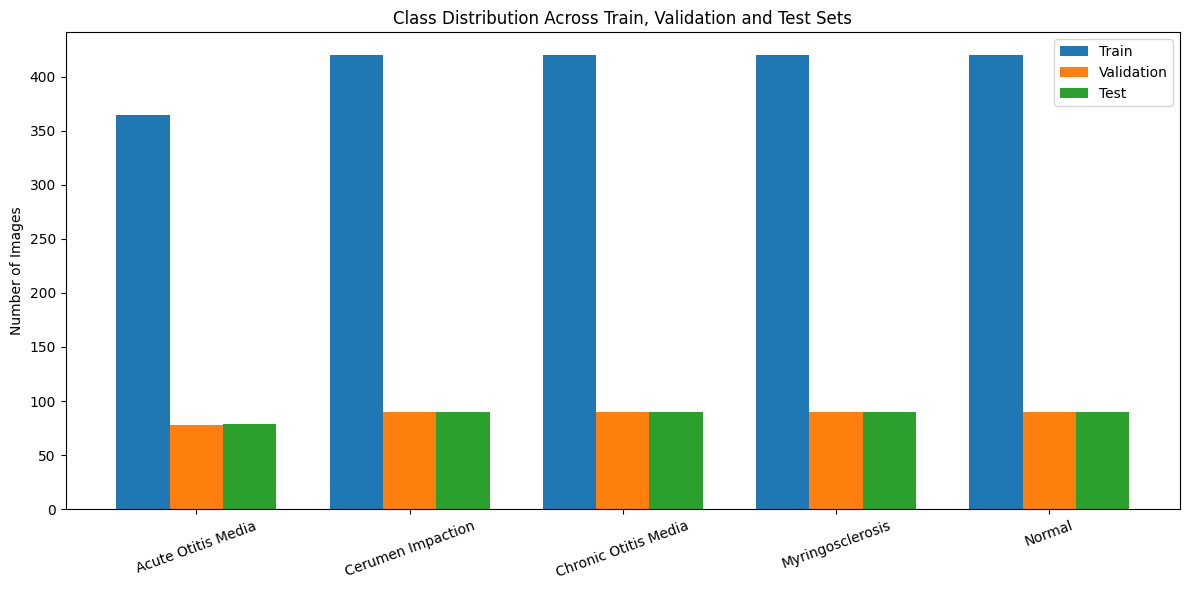

In [18]:
# ============================================================
# Cell 12 — Visualize Train/Validation/Test Distribution
# ============================================================

classes = list(dataset.class_to_idx.keys())

train_counts = [
    train_distribution[cls]
    for cls in classes
]

val_counts = [
    val_distribution[cls]
    for cls in classes
]

test_counts = [
    test_distribution[cls]
    for cls in classes
]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    train_counts,
    width,
    label="Train"
)

plt.bar(
    x,
    val_counts,
    width,
    label="Validation"
)

plt.bar(
    x + width,
    test_counts,
    width,
    label="Test"
)

plt.xticks(
    x,
    classes,
    rotation=20
)

plt.ylabel("Number of Images")
plt.title("Class Distribution Across Train, Validation and Test Sets")

plt.legend()
plt.tight_layout()
plt.show()

# 4. Augmentation

In [19]:
# ============================================================
# Cell 13 — Training, Validation and Test Transforms
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ------------------------------------------------------------
# Training Transform
# ------------------------------------------------------------

train_transform = T.Compose([

    T.Resize((640, 640)),

    # Geometric augmentation
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),

    # Appearance augmentation
    T.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05
    ),

    T.RandomAutocontrast(p=0.5),

    # Mild blur to reduce pixel-level memorization
    T.GaussianBlur(
        kernel_size=(5, 9),
        sigma=(0.1, 1.0)
    ),

    T.ToTensor(),

    # ImageNet normalization
    T.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Validation Transform
# No random augmentation
# ------------------------------------------------------------

val_transform = T.Compose([

    T.Resize((640, 640)),

    T.ToTensor(),

    T.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Test Transform
# No random augmentation
# ------------------------------------------------------------

test_transform = T.Compose([

    T.Resize((640, 640)),

    T.ToTensor(),

    T.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


print("✓ Training augmentation configured")
print("✓ Validation preprocessing configured")
print("✓ Test preprocessing configured")

✓ Training augmentation configured
✓ Validation preprocessing configured
✓ Test preprocessing configured


In [20]:
# ============================================================
# Cell 14 — Create Train, Validation and Test Datasets
# ============================================================

train_data = OtoscopicDataset(
    root_dir=train_root,
    image_paths=train_paths,
    labels=train_labels,
    categories=dataset.categories,
    class_to_idx=dataset.class_to_idx,
    transform=train_transform
)

val_data = OtoscopicDataset(
    root_dir=train_root,
    image_paths=val_paths,
    labels=val_labels,
    categories=dataset.categories,
    class_to_idx=dataset.class_to_idx,
    transform=val_transform
)

test_data = OtoscopicDataset(
    root_dir=train_root,
    image_paths=test_paths,
    labels=test_labels,
    categories=dataset.categories,
    class_to_idx=dataset.class_to_idx,
    transform=test_transform
)

print("============================================")
print("DATASET OBJECTS")
print("============================================")

print(f"Training set   : {len(train_data)}")
print(f"Validation set : {len(val_data)}")
print(f"Test set       : {len(test_data)}")

DATASET OBJECTS
Training set   : 2045
Validation set : 438
Test set       : 439


In [21]:
# ============================================================
# Cell 15 — DataLoaders
# ============================================================

BATCH_SIZE = 8

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)

print("✓ Train DataLoader created")
print("✓ Validation DataLoader created")
print("✓ Test DataLoader created")
print(f"Batch size: {BATCH_SIZE}")

✓ Train DataLoader created
✓ Validation DataLoader created
✓ Test DataLoader created
Batch size: 8


# 5. Model

In [22]:
# ============================================================
# 5. Model
# Cell 16 — Faster R-CNN with ResNet-101 + FPN
# ============================================================

class TwoMLPHeadWithDropout(nn.Module):
    """
    Faster R-CNN ROI box head with dropout
    for reducing overfitting.
    """

    def __init__(
        self,
        in_channels,
        representation_size,
        dropout_p=0.5
    ):
        super().__init__()

        self.fc6 = nn.Linear(
            in_channels,
            representation_size
        )

        self.dropout1 = nn.Dropout(
            p=dropout_p
        )

        self.fc7 = nn.Linear(
            representation_size,
            representation_size
        )

        self.dropout2 = nn.Dropout(
            p=dropout_p
        )

    def forward(self, x):

        x = x.flatten(start_dim=1)

        x = F.relu(self.fc6(x))
        x = self.dropout1(x)

        x = F.relu(self.fc7(x))
        x = self.dropout2(x)

        return x

In [23]:
# ============================================================
# Cell 17 — Build Faster R-CNN Model
# ============================================================

NUM_CLASSES = len(dataset.categories) + 1
# +1 = Background class

backbone = resnet_fpn_backbone(
    backbone_name="resnet101",
    weights="ResNet101_Weights.DEFAULT",
    trainable_layers=1
)

model = FasterRCNN(
    backbone=backbone,
    num_classes=NUM_CLASSES,
    image_mean=IMAGENET_MEAN,
    image_std=IMAGENET_STD
)

# ------------------------------------------------------------
# Replace default ROI box head with dropout version
# ------------------------------------------------------------

in_channels = model.roi_heads.box_head.fc6.in_features
representation_size = model.roi_heads.box_head.fc7.out_features

model.roi_heads.box_head = TwoMLPHeadWithDropout(
    in_channels=in_channels,
    representation_size=representation_size,
    dropout_p=0.5
)

# ------------------------------------------------------------
# Replace classifier predictor
# ------------------------------------------------------------

model.roi_heads.box_predictor = FastRCNNPredictor(
    representation_size,
    NUM_CLASSES
)

model = model.to(device)

print("✓ Faster R-CNN model created")
print("✓ Backbone: ResNet-101 + FPN")
print("✓ Trainable backbone layers: 1")
print("✓ Dropout: 0.5")
print("✓ Number of classes:", NUM_CLASSES)

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:01<00:00, 154MB/s]  


✓ Faster R-CNN model created
✓ Backbone: ResNet-101 + FPN
✓ Trainable backbone layers: 1
✓ Dropout: 0.5
✓ Number of classes: 6


In [24]:
# ============================================================
# Cell 18 — Model Parameter Analysis
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = total_params - trainable_params

print("============================================")
print("MODEL PARAMETER SUMMARY")
print("============================================")

print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"Frozen parameters     : {frozen_params:,}")

print(
    f"Trainable percentage  : "
    f"{100 * trainable_params / total_params:.2f}%"
)

MODEL PARAMETER SUMMARY
Total parameters      : 60,259,565
Trainable parameters  : 32,806,957
Frozen parameters     : 27,452,608
Trainable percentage  : 54.44%


# 6. Training

In [25]:
# ============================================================

# Cell 19 — Optimizer and Learning Rate Scheduler
# ============================================================

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=5e-5,
    weight_decay=1e-2
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("✓ Optimizer: AdamW")
print("✓ Learning rate: 5e-5")
print("✓ Weight decay: 1e-2")
print("✓ Scheduler: ReduceLROnPlateau")

✓ Optimizer: AdamW
✓ Learning rate: 5e-5
✓ Weight decay: 1e-2
✓ Scheduler: ReduceLROnPlateau


In [26]:
# ============================================================
# Cell 20 — Training Configuration
# ============================================================

NUM_EPOCHS = 10

EARLY_STOPPING_PATIENCE = 3

GRAD_CLIP_NORM = 5.0

best_val_loss = float("inf")
best_model_state = None

patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "learning_rate": []
}

print("============================================")
print("TRAINING CONFIGURATION")
print("============================================")

print(f"Maximum epochs          : {NUM_EPOCHS}")
print(f"Early stopping patience : {EARLY_STOPPING_PATIENCE}")
print(f"Gradient clipping norm  : {GRAD_CLIP_NORM}")

TRAINING CONFIGURATION
Maximum epochs          : 10
Early stopping patience : 3
Gradient clipping norm  : 5.0


In [27]:
# ============================================================
# Cell 21 — Training Loop
# ============================================================

for epoch in range(NUM_EPOCHS):

    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    running_train_loss = 0.0

    train_loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Train]"
    )

    for imgs, targets in train_loop:

        imgs = [
            img.to(device)
            for img in imgs
        ]

        targets = [
            {
                k: v.to(device)
                for k, v in target.items()
            }
            for target in targets
        ]

        # Forward pass
        loss_dict = model(
            imgs,
            targets
        )

        # Total Faster R-CNN loss
        losses = sum(
            loss
            for loss in loss_dict.values()
        )

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        losses.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP_NORM
        )

        # Update weights
        optimizer.step()

        running_train_loss += losses.item()

        train_loop.set_postfix(
            loss=f"{losses.item():.4f}"
        )

    train_loss = (
        running_train_loss /
        len(train_loader)
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.train()

    running_val_loss = 0.0

    with torch.no_grad():

        val_loop = tqdm(
            val_loader,
            desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Val]"
        )

        for imgs, targets in val_loop:

            imgs = [
                img.to(device)
                for img in imgs
            ]

            targets = [
                {
                    k: v.to(device)
                    for k, v in target.items()
                }
                for target in targets
            ]

            # Faster R-CNN returns losses in train mode
            loss_dict = model(
                imgs,
                targets
            )

            losses = sum(
                loss
                for loss in loss_dict.values()
            )

            running_val_loss += losses.item()

            val_loop.set_postfix(
                loss=f"{losses.item():.4f}"
            )

    val_loss = (
        running_val_loss /
        len(val_loader)
    )


    # ========================================================
    # RECORD HISTORY
    # ========================================================

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["learning_rate"].append(
        current_lr
    )


    print("\n--------------------------------------------")

    print(
        f"Epoch {epoch + 1}: "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f} | "
        f"LR = {current_lr:.2e}"
    )


    # ========================================================
    # LEARNING RATE SCHEDULER
    # ========================================================

    scheduler.step(val_loss)


    # ========================================================
    # BEST MODEL CHECKPOINT
    # ========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            best_model_state,
            "best_model.pt"
        )

        patience_counter = 0

        print(
            "✓ Validation improved — "
            "best model saved."
        )

    else:

        patience_counter += 1

        print(
            f"⚠ No validation improvement "
            f"({patience_counter}/"
            f"{EARLY_STOPPING_PATIENCE})"
        )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if patience_counter >= EARLY_STOPPING_PATIENCE:

        print("\nEarly stopping triggered.")

        break


# ============================================================
# RESTORE BEST MODEL
# ============================================================

if best_model_state is not None:

    model.load_state_dict(
        best_model_state
    )

    print(
        "\n✓ Best validation model restored."
    )

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

Epoch 1/10 [Val]: 100%|██████████| 55/55 [01:06<00:00,  1.20s/it, loss=0.1893]



--------------------------------------------
Epoch 1: Train Loss = 0.7830 | Val Loss = 0.2137 | LR = 5.00e-05
✓ Validation improved — best model saved.


Epoch 2/10 [Val]: 100%|██████████| 55/55 [01:05<00:00,  1.20s/it, loss=0.1477]



--------------------------------------------
Epoch 2: Train Loss = 0.1954 | Val Loss = 0.1604 | LR = 5.00e-05
✓ Validation improved — best model saved.


Epoch 3/10 [Val]: 100%|██████████| 55/55 [01:06<00:00,  1.21s/it, loss=0.1335]


...


--------------------------------------------
Epoch 8: Train Loss = 0.1201 | Val Loss = 0.1087 | LR = 5.00e-05
✓ Validation improved — best model saved.


Epoch 9/10 [Val]: 100%|██████████| 55/55 [01:06<00:00,  1.21s/it, loss=0.0767]



--------------------------------------------
Epoch 9: Train Loss = 0.1105 | Val Loss = 0.0919 | LR = 5.00e-05
✓ Validation improved — best model saved.


Epoch 10/10 [Val]: 100%|██████████| 55/55 [01:06<00:00,  1.21s/it, loss=0.0800]


--------------------------------------------
Epoch 10: Train Loss = 0.1075 | Val Loss = 0.1060 | LR = 5.00e-05
⚠ No validation improvement (1/3)

✓ Best validation model restored.
Best validation loss: 0.0919


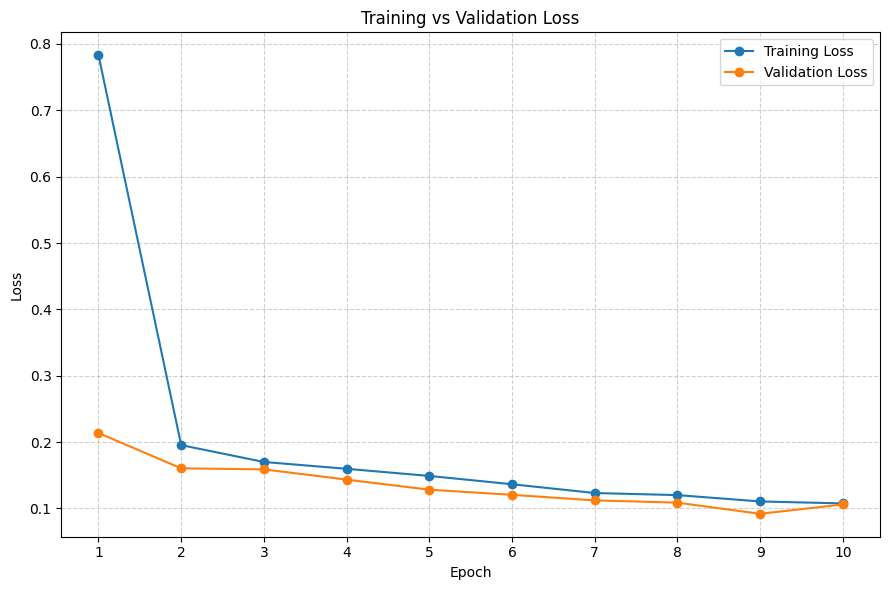

In [28]:
# ============================================================
# Cell 22 — Training and Validation Loss Curves
# ============================================================

epochs_ran = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(9, 6))

plt.plot(
    epochs_ran,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_ran,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.xticks(
    list(epochs_ran)
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.6
)

plt.legend()

plt.tight_layout()

plt.show()

# 7. Validation

In [ ]:
# ============================================================
# Cell 23 — Validation Set Prediction and Metrics
# ============================================================

model.eval()

all_val_preds = []
all_val_labels = []
all_val_scores = []

with torch.no_grad():

    for imgs, targets in tqdm(
        val_loader,
        desc="Validating"
    ):

        imgs = [
            img.to(device)
            for img in imgs
        ]

        outputs = model(imgs)

        for i, output in enumerate(outputs):

            true_label = targets[i]["labels"][0].item()

            all_val_labels.append(true_label)

            # Keep only detected objects
            if len(output["labels"]) > 0:

                best_idx = torch.argmax(
                    output["scores"]
                )

                predicted_label = (
                    output["labels"][best_idx].item()
                )

                prediction_score = (
                    output["scores"][best_idx].item()
                )

            else:

                predicted_label = 0
                prediction_score = 0.0

            all_val_preds.append(
                predicted_label
            )

            all_val_scores.append(
                prediction_score
            )


# ------------------------------------------------------------
# Validation Metrics
# ------------------------------------------------------------

class_indices = list(
    range(1, len(dataset.categories) + 1)
)

print("\n============================================")
print("VALIDATION SET CLASSIFICATION REPORT")
print("============================================")

print(
    classification_report(
        all_val_labels,
        all_val_preds,
        labels=class_indices,
        target_names=dataset.categories,
        digits=4,
        zero_division=0
    )
)

val_accuracy = accuracy_score(
    all_val_labels,
    all_val_preds
)

val_precision, val_recall, val_f1, _ = (
    precision_recall_fscore_support(
        all_val_labels,
        all_val_preds,
        labels=class_indices,
        average="macro",
        zero_division=0
    )
)

print("--------------------------------------------")
print(f"Validation Accuracy      : {val_accuracy:.4f}")
print(f"Validation Macro Precision: {val_precision:.4f}")
print(f"Validation Macro Recall   : {val_recall:.4f}")
print(f"Validation Macro F1       : {val_f1:.4f}")

Validating: 100%|██████████| 55/55 [01:07<00:00,  1.23s/it]


VALIDATION SET CLASSIFICATION REPORT
                      precision    recall  f1-score   support

  Acute Otitis Media     1.0000    1.0000    1.0000        78
   Cerumen Impaction     1.0000    1.0000    1.0000        90
Chronic Otitis Media     1.0000    1.0000    1.0000        90
    Myringosclerosis     1.0000    1.0000    1.0000        90
              Normal     1.0000    1.0000    1.0000        90

            accuracy                         1.0000       438
           macro avg     1.0000    1.0000    1.0000       438
        weighted avg     1.0000    1.0000    1.0000       438

--------------------------------------------
Validation Accuracy      : 1.0000
Validation Macro Precision: 1.0000
Validation Macro Recall   : 1.0000
Validation Macro F1       : 1.0000


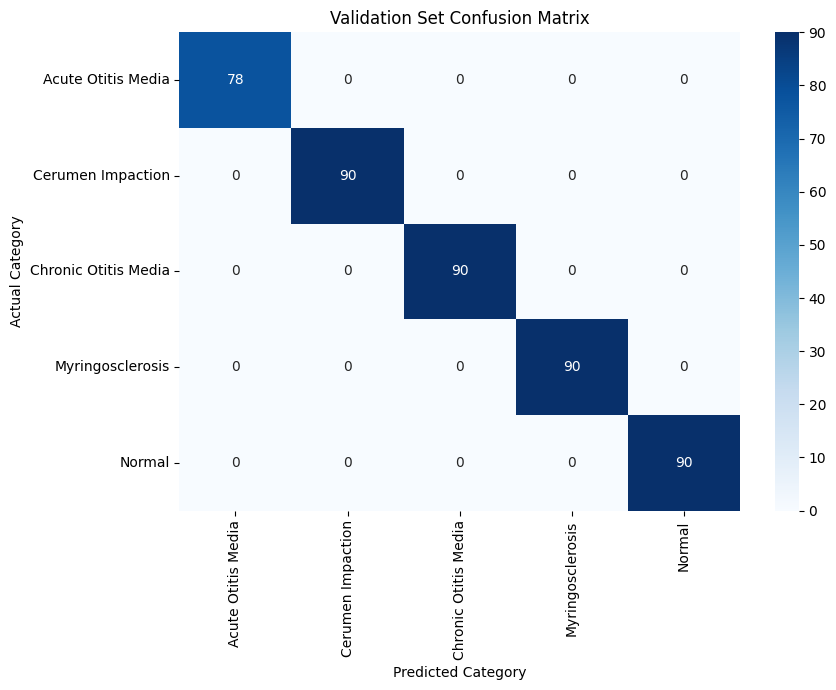

In [ ]:
# ============================================================
# Cell 24 — Validation Confusion Matrix
# ============================================================

val_cm = confusion_matrix(
    all_val_labels,
    all_val_preds,
    labels=class_indices
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    val_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.categories,
    yticklabels=dataset.categories
)

plt.title("Validation Set Confusion Matrix")

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.tight_layout()
plt.show()

# 8. Internal Test

In [ ]:
# ============================================================

# Cell 25 — Internal Test Evaluation
# ============================================================

model.eval()

all_test_preds = []
all_test_labels = []
all_test_scores = []

with torch.no_grad():

    for imgs, targets in tqdm(
        test_loader,
        desc="Testing"
    ):

        imgs = [
            img.to(device)
            for img in imgs
        ]

        outputs = model(imgs)

        for i, output in enumerate(outputs):

            true_label = targets[i]["labels"][0].item()

            all_test_labels.append(true_label)

            # Select highest-confidence detection
            if len(output["labels"]) > 0:

                best_idx = torch.argmax(
                    output["scores"]
                )

                predicted_label = (
                    output["labels"][best_idx].item()
                )

                prediction_score = (
                    output["scores"][best_idx].item()
                )

            else:

                predicted_label = 0
                prediction_score = 0.0

            all_test_preds.append(
                predicted_label
            )

            all_test_scores.append(
                prediction_score
            )


# ------------------------------------------------------------
# Test Metrics
# ------------------------------------------------------------

class_indices = list(
    range(1, len(dataset.categories) + 1)
)

print("\n============================================")
print("INTERNAL TEST SET CLASSIFICATION REPORT")
print("============================================")

print(
    classification_report(
        all_test_labels,
        all_test_preds,
        labels=class_indices,
        target_names=dataset.categories,
        digits=4,
        zero_division=0
    )
)

test_accuracy = accuracy_score(
    all_test_labels,
    all_test_preds
)

test_precision, test_recall, test_f1, _ = (
    precision_recall_fscore_support(
        all_test_labels,
        all_test_preds,
        labels=class_indices,
        average="macro",
        zero_division=0
    )
)

print("--------------------------------------------")
print(f"Test Accuracy       : {test_accuracy:.4f}")
print(f"Test Macro Precision: {test_precision:.4f}")
print(f"Test Macro Recall   : {test_recall:.4f}")
print(f"Test Macro F1       : {test_f1:.4f}")

Testing: 100%|██████████| 55/55 [01:08<00:00,  1.24s/it]


INTERNAL TEST SET CLASSIFICATION REPORT
                      precision    recall  f1-score   support

  Acute Otitis Media     1.0000    1.0000    1.0000        79
   Cerumen Impaction     1.0000    1.0000    1.0000        90
Chronic Otitis Media     1.0000    1.0000    1.0000        90
    Myringosclerosis     1.0000    1.0000    1.0000        90
              Normal     1.0000    1.0000    1.0000        90

            accuracy                         1.0000       439
           macro avg     1.0000    1.0000    1.0000       439
        weighted avg     1.0000    1.0000    1.0000       439

--------------------------------------------
Test Accuracy       : 1.0000
Test Macro Precision: 1.0000
Test Macro Recall   : 1.0000
Test Macro F1       : 1.0000


## 8.1 internal test confusion matrix

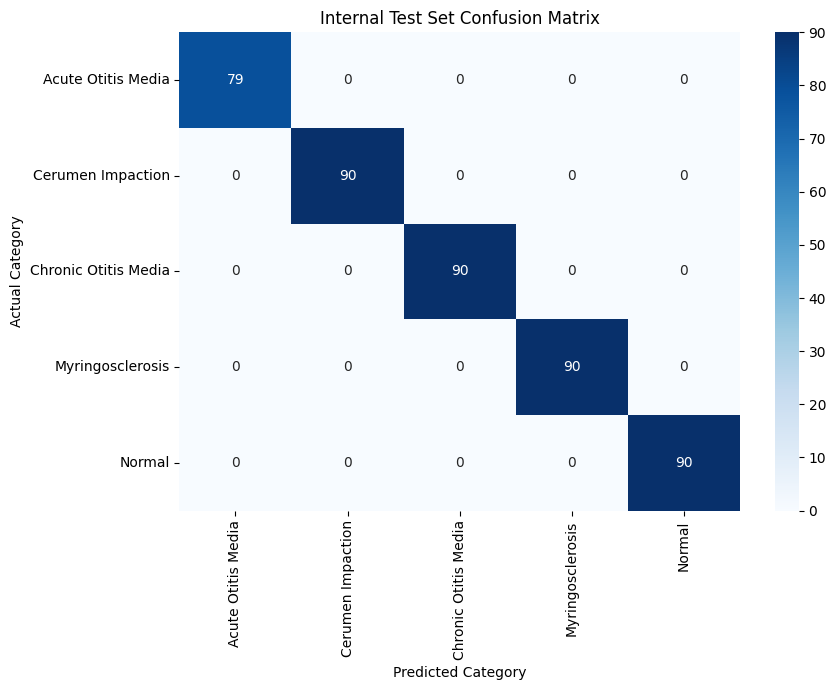

In [ ]:
# ============================================================
# Cell 26 — Internal Test Confusion Matrix
# ============================================================

test_cm = confusion_matrix(
    all_test_labels,
    all_test_preds,
    labels=class_indices
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.categories,
    yticklabels=dataset.categories
)

plt.title("Internal Test Set Confusion Matrix")

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.tight_layout()
plt.show()

# 9. Duplicate Analysis

In [ ]:
# ============================================================

# Cell 27 — Generate Perceptual Hashes
# ============================================================

!pip -q install ImageHash

import imagehash

def calculate_phash(image_path):
    """
    Calculate perceptual hash (pHash) for an image.
    """
    with Image.open(image_path) as img:
        return imagehash.phash(
            img.convert("RGB")
        )


print("Calculating perceptual hashes...")

train_hashes = {
    path: calculate_phash(path)
    for path in tqdm(
        train_paths,
        desc="Train"
    )
}

val_hashes = {
    path: calculate_phash(path)
    for path in tqdm(
        val_paths,
        desc="Validation"
    )
}

test_hashes = {
    path: calculate_phash(path)
    for path in tqdm(
        test_paths,
        desc="Test"
    )
}

print("\n✓ Perceptual hashes generated.")

Calculating perceptual hashes...


Test: 100%|██████████| 439/439 [00:02<00:00, 177.35it/s]


✓ Perceptual hashes generated.


In [ ]:
# ============================================================
# Cell 28 — Train ↔ Validation Near-Duplicate Analysis
# ============================================================

PHASH_THRESHOLD = 5

train_val_duplicates = []

for train_path, train_hash in train_hashes.items():

    for val_path, val_hash in val_hashes.items():

        distance = train_hash - val_hash

        if distance <= PHASH_THRESHOLD:

            train_val_duplicates.append({
                "train": train_path,
                "validation": val_path,
                "distance": distance
            })


print("============================================")
print("TRAIN ↔ VALIDATION DUPLICATE ANALYSIS")
print("============================================")

print(
    f"Near-duplicate pairs: "
    f"{len(train_val_duplicates)}"
)

if len(train_val_duplicates) == 0:

    print("✓ No near-duplicate leakage detected.")

else:

    print("⚠ Near-duplicate pairs detected.")

    for pair in train_val_duplicates[:20]:

        print(
            f"\nDistance: {pair['distance']}"
        )

        print(
            "Train:",
            os.path.basename(pair["train"])
        )

        print(
            "Validation:",
            os.path.basename(pair["validation"])
        )

TRAIN ↔ VALIDATION DUPLICATE ANALYSIS
Near-duplicate pairs: 329
⚠ Near-duplicate pairs detected.

Distance: 0
Train: norm (32).jpg
Validation: norm (28).jpg

Distance: 2
Train: ci (377).jpg
Validation: ci (376).jpg

Distance: 4
Train: mys (40).jpg
Validation: mys (42).jpg

Distance: 2
Train: norm (317).jpg
Validation: norm (345).jpg

Distance: 2
Train: ci (364).jpg
Validation: ci (365).jpg

Distance: 2
Train: ci (461).jpg
Validation: ci (463).jpg

Distance: 4
Train: norm (320).jpg
Validation: norm (326).jpg

Distance: 2
Train: norm (157).jpg
Validation: norm (154).jpg

Distance: 2
Train: ci (309).jpg
Validation: ci (311).jpg

Distance: 4
Train: ci (295).jpg
Validation: ci (287).jpg

Distance: 4
Train: ci (132).jpg
Validation: ci (129).jpg

Distance: 2
Train: ci (245).jpg
Validation: ci (250).jpg

Distance: 2
Train: ci (245).jpg
Validation: ci (246).jpg

Distance: 4
Train: com (238).jpg
Validation: com (233).jpg

Distance: 2
Train: norm (99).jpg
Validation: norm (97).jpg

Distance: 4
Tr

In [ ]:
# ============================================================
# Cell 29 — Train ↔ Test Near-Duplicate Analysis
# ============================================================

train_test_duplicates = []

for train_path, train_hash in train_hashes.items():

    for test_path, test_hash in test_hashes.items():

        distance = train_hash - test_hash

        if distance <= PHASH_THRESHOLD:

            train_test_duplicates.append({
                "train": train_path,
                "test": test_path,
                "distance": distance
            })


print("============================================")
print("TRAIN ↔ TEST DUPLICATE ANALYSIS")
print("============================================")

print(
    f"Near-duplicate pairs: "
    f"{len(train_test_duplicates)}"
)

if len(train_test_duplicates) == 0:

    print("✓ No near-duplicate leakage detected.")

else:

    print("⚠ Near-duplicate pairs detected.")

    for pair in train_test_duplicates[:20]:

        print(
            f"\nDistance: {pair['distance']}"
        )

        print(
            "Train:",
            os.path.basename(pair["train"])
        )

        print(
            "Test:",
            os.path.basename(pair["test"])
        )

TRAIN ↔ TEST DUPLICATE ANALYSIS
Near-duplicate pairs: 338
⚠ Near-duplicate pairs detected.

Distance: 4
Train: mys (324).jpg
Test: mys (321).jpg

Distance: 4
Train: mys (587).jpg
Test: mys (576).jpg

Distance: 2
Train: norm (79).jpg
Test: norm (82).jpg

Distance: 4
Train: aom (109).jpg
Test: aom (136).jpg

Distance: 2
Train: ci (503).jpg
Test: ci (511).jpg

Distance: 4
Train: mys (418).jpg
Test: mys (419).jpg

Distance: 4
Train: ci (546).jpg
Test: ci (541).jpg

Distance: 4
Train: ci (132).jpg
Test: ci (139).jpg

Distance: 4
Train: com (238).jpg
Test: com (242).jpg

Distance: 4
Train: norm (99).jpg
Test: norm (96).jpg

Distance: 4
Train: ci (148).jpg
Test: ci (143).jpg

Distance: 4
Train: ci (135).jpg
Test: ci (139).jpg

Distance: 0
Train: norm (590).jpg
Test: norm (592).jpg

Distance: 2
Train: mys (247).jpg
Test: mys (241).jpg

Distance: 2
Train: mys (247).jpg
Test: mys (237).jpg

Distance: 0
Train: com (138).jpg
Test: com (139).jpg

Distance: 4
Train: norm (504).jpg
Test: norm (502).j

In [ ]:
# ============================================================
# Cell 30 — Validation ↔ Test Near-Duplicate Analysis
# ============================================================

val_test_duplicates = []

for val_path, val_hash in val_hashes.items():

    for test_path, test_hash in test_hashes.items():

        distance = val_hash - test_hash

        if distance <= PHASH_THRESHOLD:

            val_test_duplicates.append({
                "validation": val_path,
                "test": test_path,
                "distance": distance
            })


print("============================================")
print("VALIDATION ↔ TEST DUPLICATE ANALYSIS")
print("============================================")

print(
    f"Near-duplicate pairs: "
    f"{len(val_test_duplicates)}"
)

if len(val_test_duplicates) == 0:

    print("✓ No near-duplicate leakage detected.")

else:

    print("⚠ Near-duplicate pairs detected.")

    for pair in val_test_duplicates[:20]:

        print(
            f"\nDistance: {pair['distance']}"
        )

        print(
            "Validation:",
            os.path.basename(pair["validation"])
        )

        print(
            "Test:",
            os.path.basename(pair["test"])
        )

VALIDATION ↔ TEST DUPLICATE ANALYSIS
Near-duplicate pairs: 70
⚠ Near-duplicate pairs detected.

Distance: 4
Validation: aom (390).jpg
Test: aom (382).jpg

Distance: 2
Validation: ci (318).jpg
Test: ci (320).jpg

Distance: 0
Validation: mys (198).jpg
Test: mys (201).jpg

Distance: 0
Validation: mys (198).jpg
Test: mys (200).jpg

Distance: 2
Validation: mys (198).jpg
Test: mys (207).jpg

Distance: 0
Validation: mys (198).jpg
Test: mys (199).jpg

Distance: 4
Validation: norm (77).jpg
Test: norm (189).jpg

Distance: 4
Validation: com (201).jpg
Test: com (202).jpg

Distance: 0
Validation: com (214).jpg
Test: com (223).jpg

Distance: 2
Validation: com (213).jpg
Test: com (223).jpg

Distance: 2
Validation: ci (329).jpg
Test: ci (320).jpg

Distance: 4
Validation: com (262).jpg
Test: com (260).jpg

Distance: 2
Validation: com (196).jpg
Test: com (191).jpg

Distance: 0
Validation: ci (161).jpg
Test: ci (164).jpg

Distance: 2
Validation: norm (508).jpg
Test: norm (510).jpg

Distance: 0
Validation

In [ ]:
# ============================================================
# Cell 31 — Final Duplicate / Leakage Summary
# ============================================================

print("============================================")
print("FINAL DATA LEAKAGE SUMMARY")
print("============================================")

print(
    f"Train ↔ Validation : "
    f"{len(train_val_duplicates)} pairs"
)

print(
    f"Train ↔ Test       : "
    f"{len(train_test_duplicates)} pairs"
)

print(
    f"Validation ↔ Test  : "
    f"{len(val_test_duplicates)} pairs"
)

total_cross_split_duplicates = (
    len(train_val_duplicates)
    + len(train_test_duplicates)
    + len(val_test_duplicates)
)

print("--------------------------------------------")

print(
    f"Total cross-split near-duplicate pairs: "
    f"{total_cross_split_duplicates}"
)

if total_cross_split_duplicates == 0:

    print(
        "\n✓ No cross-split near-duplicate leakage "
        "detected with the selected pHash threshold."
    )

else:

    print(
        "\n⚠ WARNING: Cross-split near-duplicates "
        "were detected."
    )

FINAL DATA LEAKAGE SUMMARY
Train ↔ Validation : 329 pairs
Train ↔ Test       : 338 pairs
Validation ↔ Test  : 70 pairs
--------------------------------------------
Total cross-split near-duplicate pairs: 737

⚠ WARNING: Cross-split near-duplicates were detected.


In [ ]:
# ============================================================
# 9. Duplicate Analysis
# Cell 32 — Build Global Near-Duplicate Groups
# ============================================================

from collections import defaultdict

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

PHASH_THRESHOLD = 5

# Use the cleaned dataset
all_clean_paths = clean_image_paths

print("Generating perceptual hashes...")

clean_hashes = {}

for path in tqdm(
    all_clean_paths,
    desc="Calculating pHash"
):
    clean_hashes[path] = calculate_phash(path)

print("\n✓ Perceptual hashes generated.")


# ------------------------------------------------------------
# Union-Find data structure
# ------------------------------------------------------------

parent = {
    path: path
    for path in all_clean_paths
}


def find_root(x):

    if parent[x] != x:
        parent[x] = find_root(parent[x])

    return parent[x]


def union(x, y):

    root_x = find_root(x)
    root_y = find_root(y)

    if root_x != root_y:
        parent[root_y] = root_x


# ------------------------------------------------------------
# Group images by class
# ------------------------------------------------------------

class_to_paths = defaultdict(list)

for path in all_clean_paths:

    class_name = os.path.basename(
        os.path.dirname(path)
    )

    class_to_paths[class_name].append(path)


# ------------------------------------------------------------
# Find near-duplicate pairs
# ------------------------------------------------------------

near_duplicate_pairs = []

for class_name, paths in class_to_paths.items():

    for i in range(len(paths)):

        for j in range(i + 1, len(paths)):

            path_a = paths[i]
            path_b = paths[j]

            distance = (
                clean_hashes[path_a]
                - clean_hashes[path_b]
            )

            if distance <= PHASH_THRESHOLD:

                union(
                    path_a,
                    path_b
                )

                near_duplicate_pairs.append(
                    (
                        path_a,
                        path_b,
                        distance
                    )
                )


# ------------------------------------------------------------
# Build connected duplicate groups
# ------------------------------------------------------------

duplicate_groups = defaultdict(list)

for path in all_clean_paths:

    root = find_root(path)

    duplicate_groups[root].append(path)


# Keep only groups containing more than one image
duplicate_groups = {
    root: members
    for root, members in duplicate_groups.items()
    if len(members) > 1
}


# ------------------------------------------------------------
# Assign unique group ID to every image
# ------------------------------------------------------------

path_to_group = {}

group_id = 0

for root, members in duplicate_groups.items():

    for path in members:
        path_to_group[path] = group_id

    group_id += 1


# Images without duplicates get their own group
for path in all_clean_paths:

    if path not in path_to_group:

        path_to_group[path] = group_id

        group_id += 1


# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

duplicate_image_count = sum(
    len(members)
    for members in duplicate_groups.values()
)

largest_duplicate_group = max(
    (len(members) for members in duplicate_groups.values()),
    default=1
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n============================================")
print("GLOBAL NEAR-DUPLICATE ANALYSIS")
print("============================================")

print(
    f"Clean images            : {len(all_clean_paths)}"
)

print(
    f"Near-duplicate pairs    : {len(near_duplicate_pairs)}"
)

print(
    f"Near-duplicate groups   : {len(duplicate_groups)}"
)

print(
    f"Images inside groups    : {duplicate_image_count}"
)

print(
    f"Total unique groups     : {group_id}"
)

print(
    f"Largest duplicate group : {largest_duplicate_group}"
)

Generating perceptual hashes...


Calculating pHash: 100%|██████████| 2922/2922 [00:16<00:00, 174.23it/s]



✓ Perceptual hashes generated.

GLOBAL NEAR-DUPLICATE ANALYSIS
Clean images            : 2922
Near-duplicate pairs    : 1654
Near-duplicate groups   : 509
Images inside groups    : 1507
Total unique groups     : 1924
Largest duplicate group : 10


In [ ]:
# ============================================================
# Cell 33 — Inspect Near-Duplicate Groups
# ============================================================

print("============================================")
print("SAMPLE NEAR-DUPLICATE GROUPS")
print("============================================")

# Sort groups from largest to smallest
sorted_duplicate_groups = sorted(
    duplicate_groups.values(),
    key=len,
    reverse=True
)

for i, members in enumerate(
    sorted_duplicate_groups[:20],
    start=1
):

    class_name = os.path.basename(
        os.path.dirname(members[0])
    )

    print(f"\nGroup {i}")
    print(f"Class  : {class_name}")
    print(f"Images : {len(members)}")

    for path in members:

        print(
            "   ",
            os.path.basename(path)
        )

SAMPLE NEAR-DUPLICATE GROUPS

Group 1
Class  : Myringosclerosis
Images : 10
    mys (5).jpg
    mys (599).jpg
    mys (600).jpg
    mys (4).jpg
    mys (1).jpg
    mys (2).jpg
    mys (6).jpg
    mys (3).jpg
    mys (7).jpg
    mys (598).jpg

Group 2
Class  : Myringosclerosis
Images : 10
    mys (303).jpg
    mys (301).jpg
    mys (302).jpg
    mys (298).jpg
    mys (306).jpg
    mys (300).jpg
    mys (299).jpg
    mys (305).jpg
    mys (307).jpg
    mys (304).jpg

Group 3
Class  : Myringosclerosis
Images : 10
    mys (406).jpg
    mys (398).jpg
    mys (401).jpg
    mys (399).jpg
    mys (405).jpg
    mys (402).jpg
    mys (404).jpg
    mys (407).jpg
    mys (403).jpg
    mys (400).jpg

Group 4
Class  : Myringosclerosis
Images : 10
    mys (96).jpg
    mys (92).jpg
    mys (90).jpg
    mys (91).jpg
    mys (93).jpg
    mys (88).jpg
    mys (94).jpg
    mys (87).jpg
    mys (95).jpg
    mys (89).jpg

Group 5
Class  : Myringosclerosis
Images : 10
    mys (201).jpg
    mys (202).jpg
    


Group 1 (10 images)


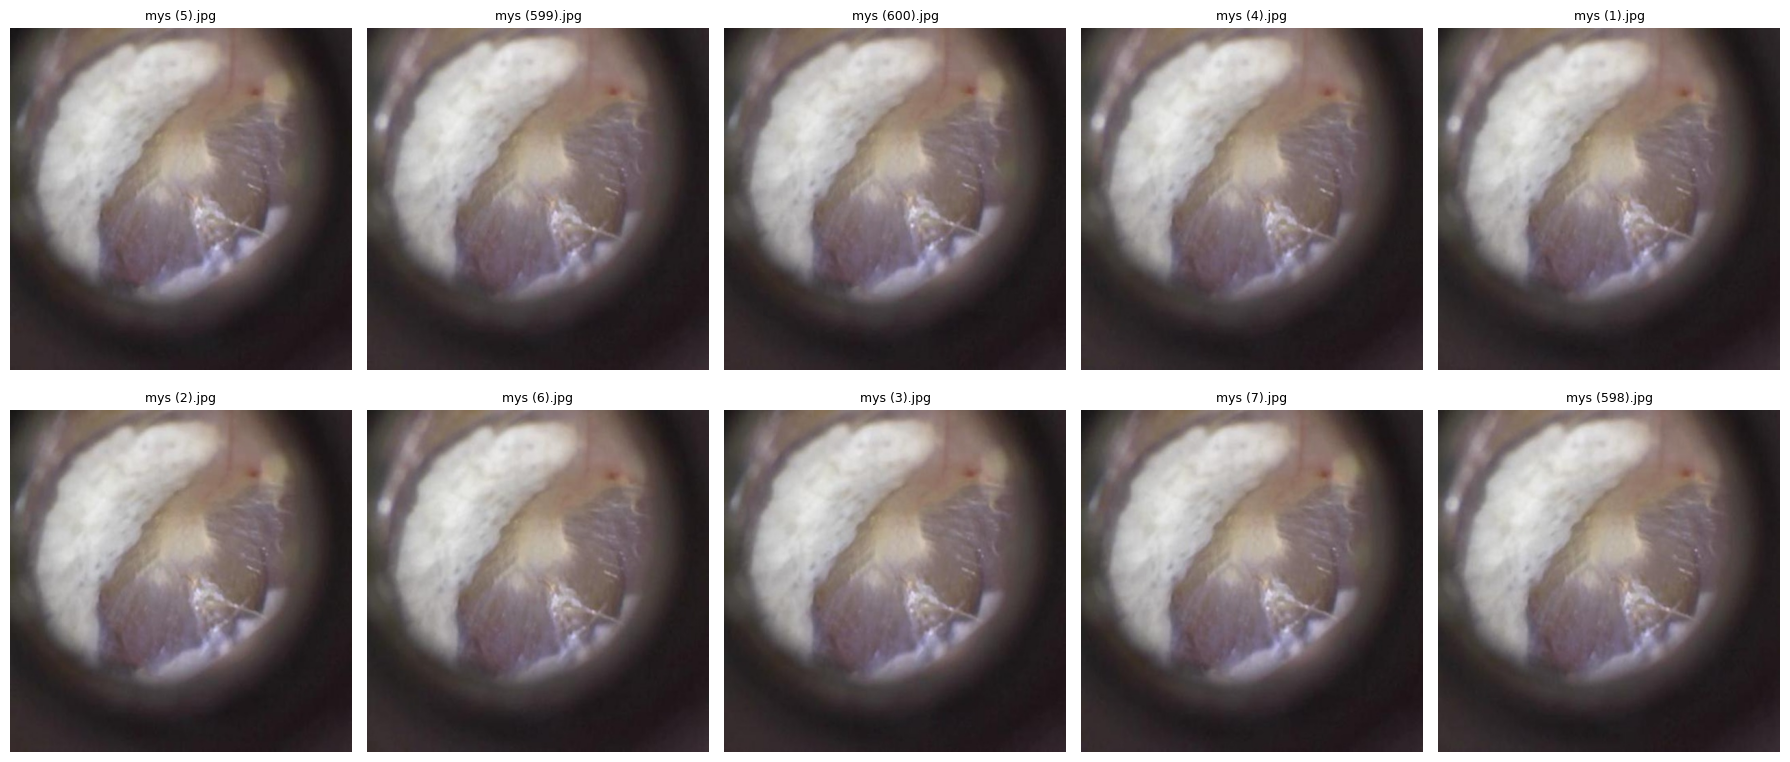


Group 2 (10 images)


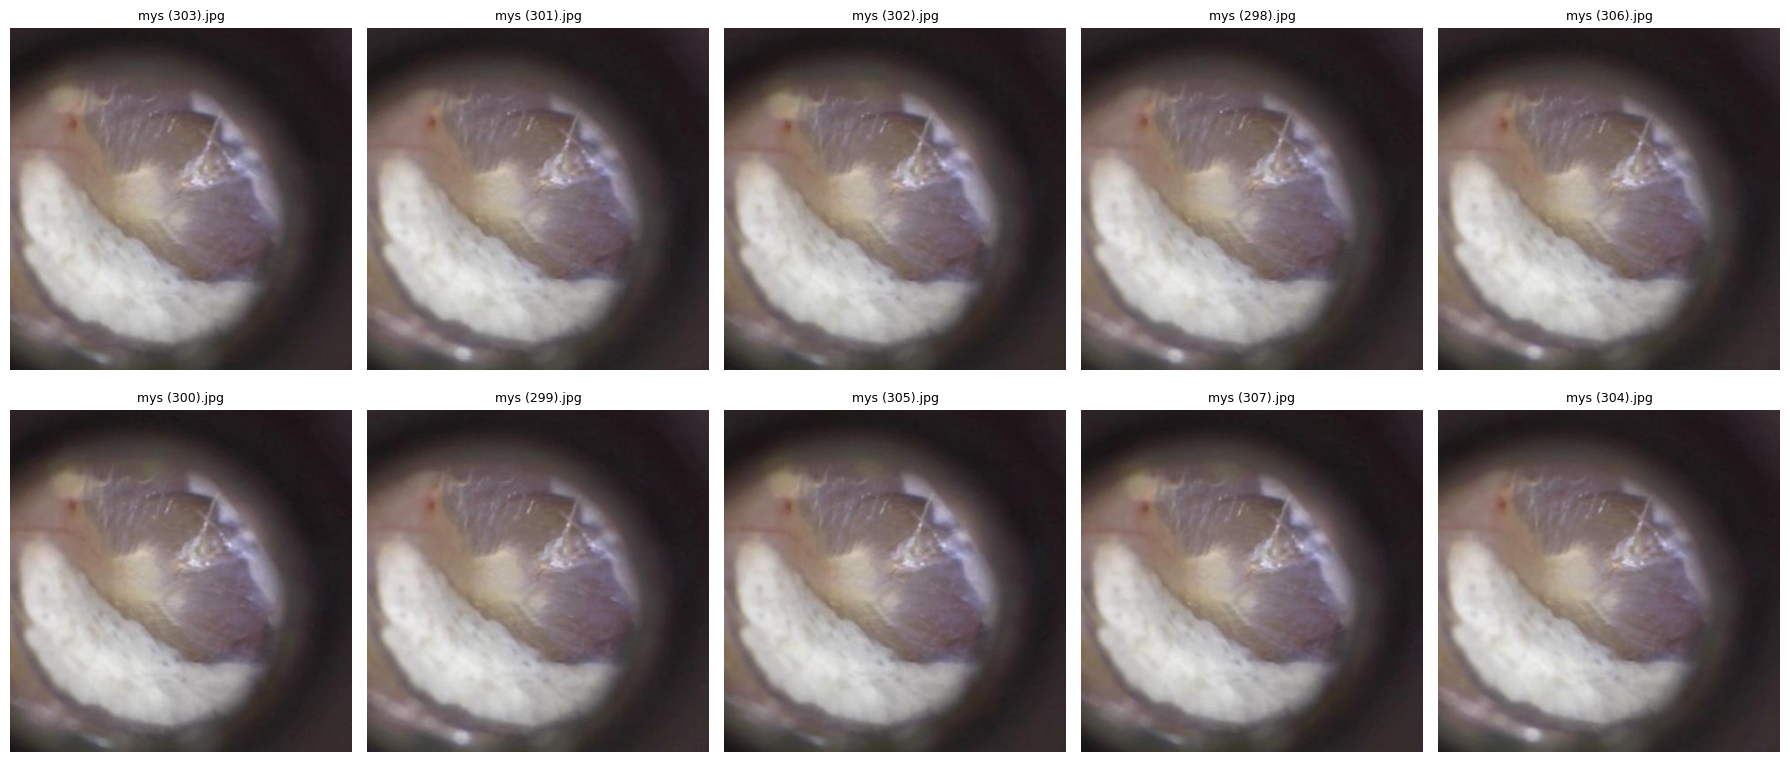


Group 3 (10 images)


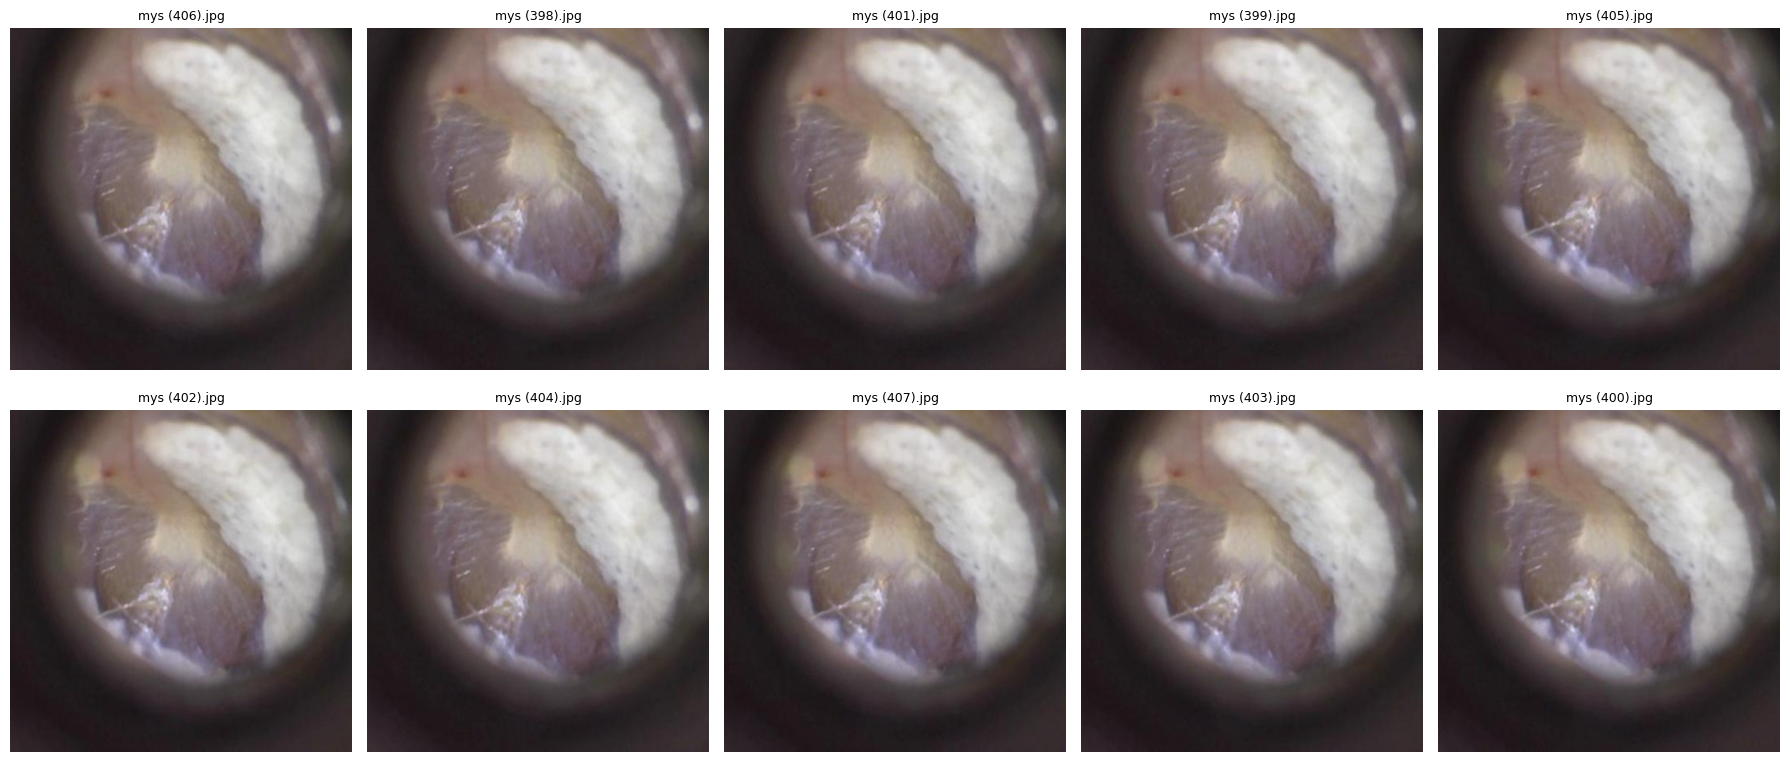


Group 4 (10 images)


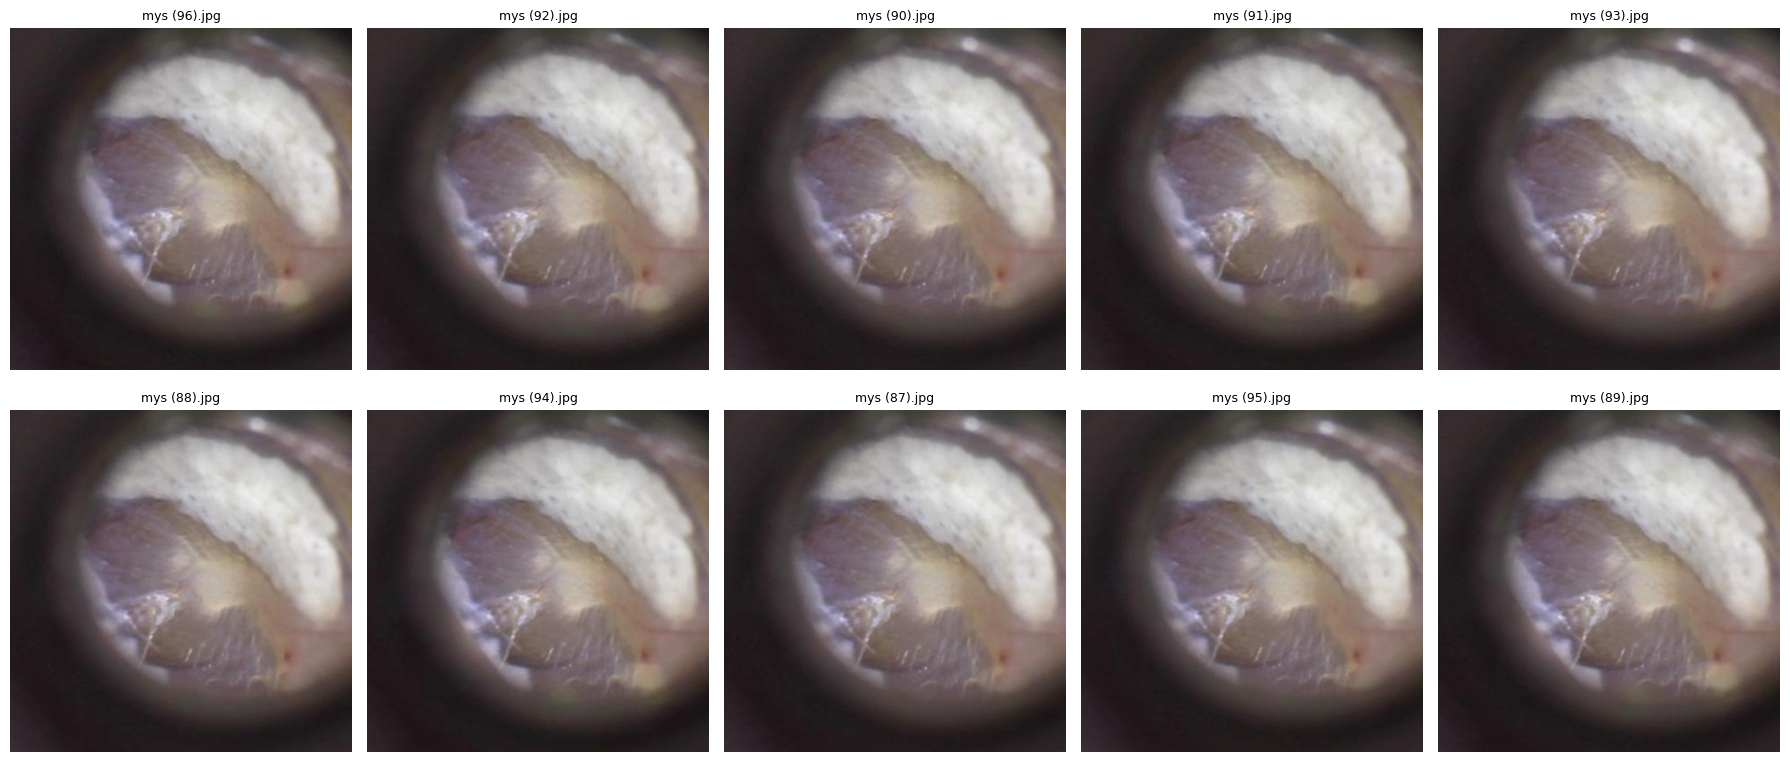


Group 5 (10 images)


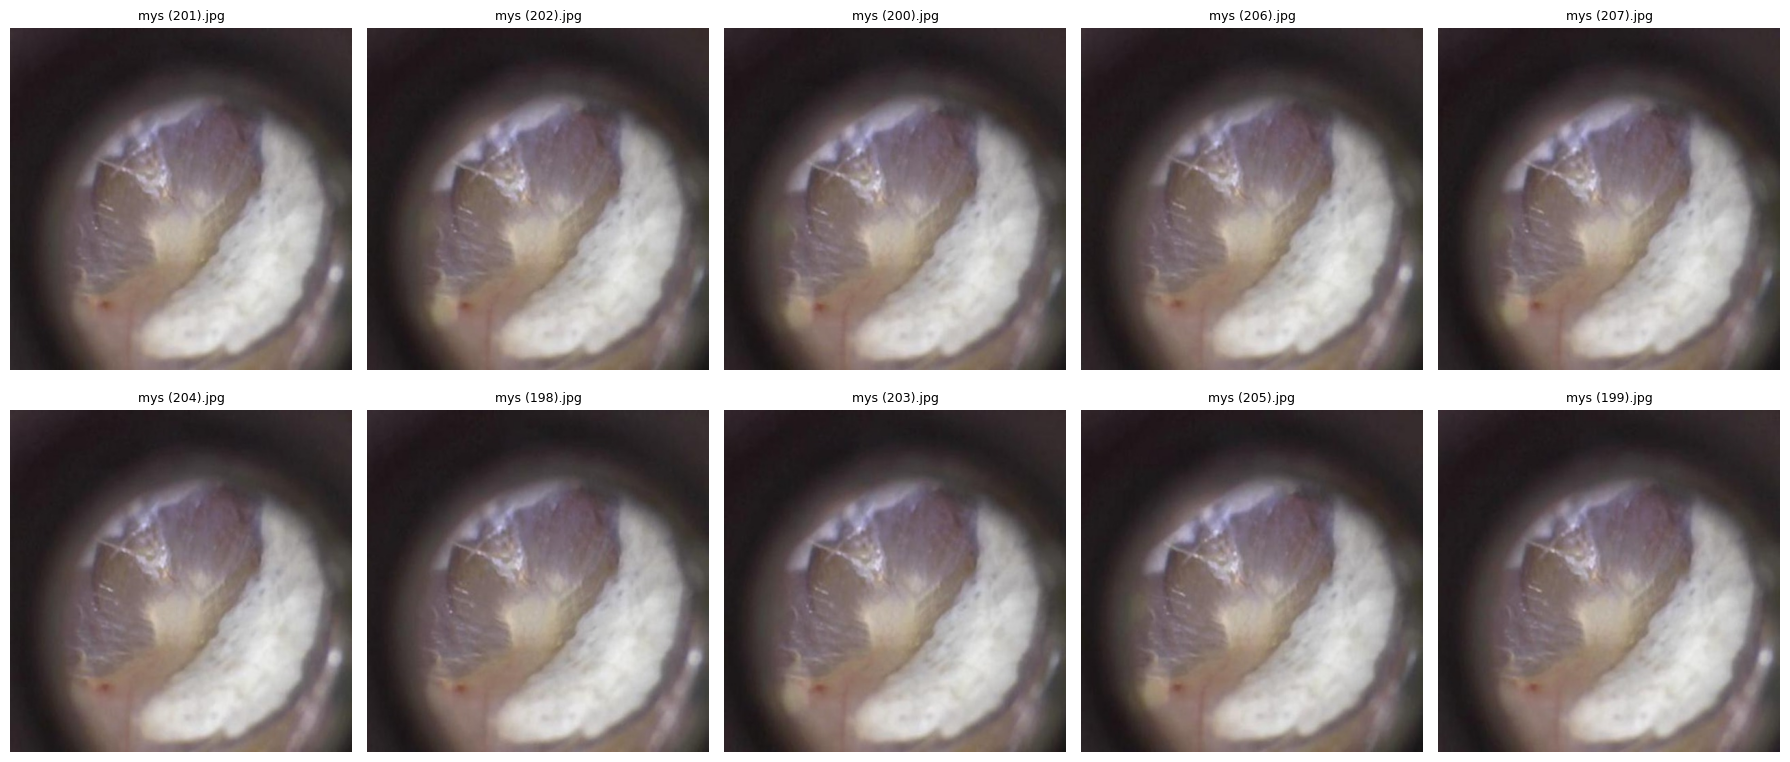


Group 6 (10 images)


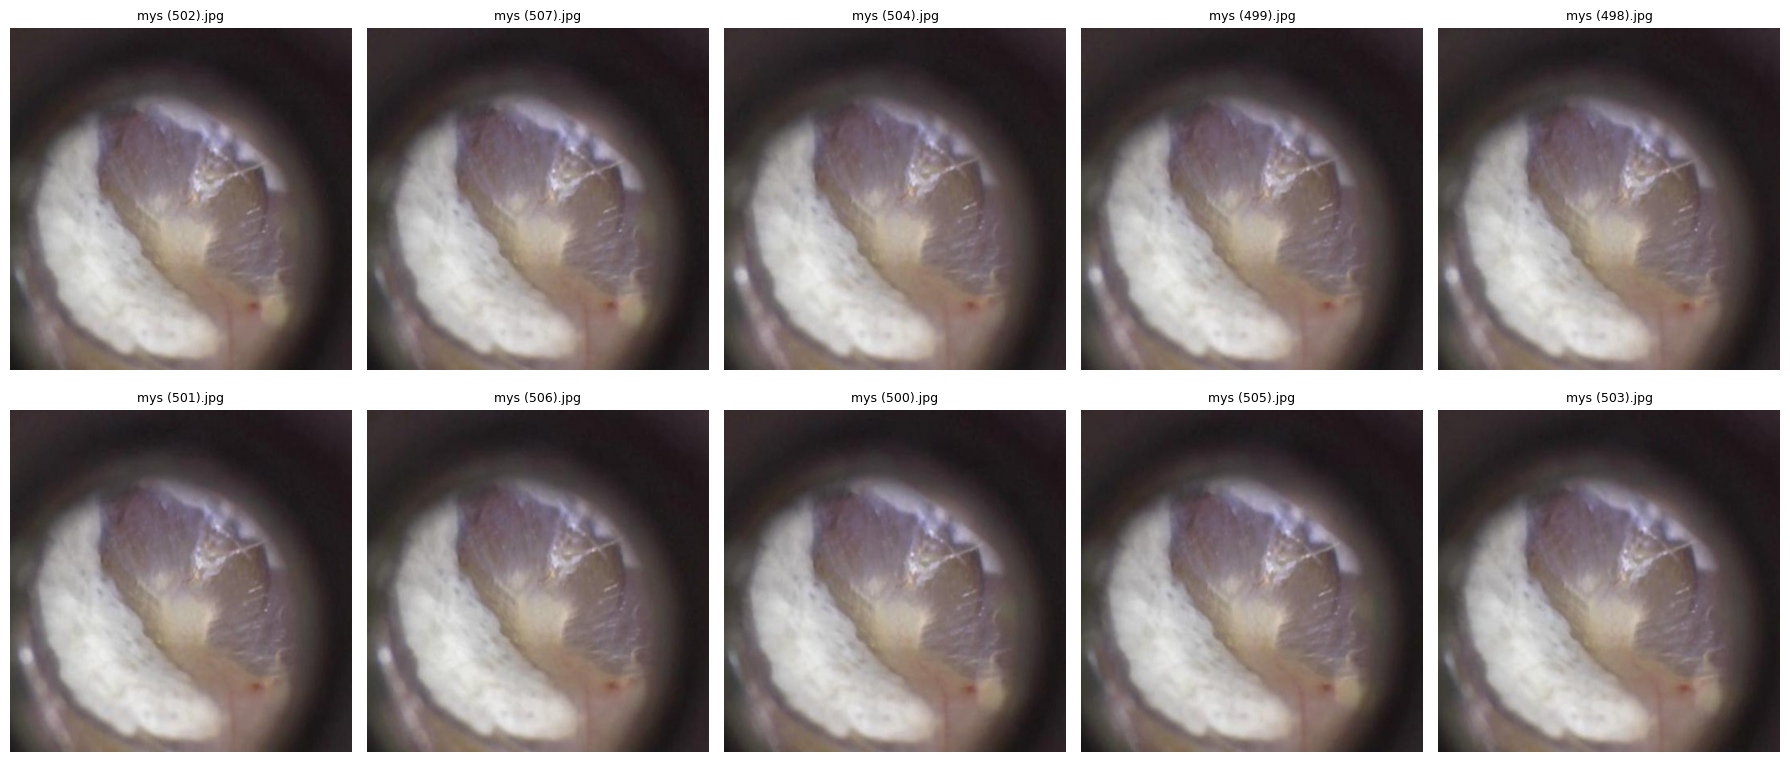

In [ ]:
# ============================================================
# 9. Duplicate Analysis
# Cell 34 — Visual Inspection of Near-Duplicate Groups
# ============================================================

def show_duplicate_group(members, max_images=10):

    members = members[:max_images]

    n = len(members)

    fig, axes = plt.subplots(
        2,
        5,
        figsize=(18, 8)
    )

    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")

    for i, path in enumerate(members):

        img = Image.open(path).convert("RGB")

        axes[i].imshow(img)

        axes[i].set_title(
            os.path.basename(path),
            fontsize=9
        )

        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Display the largest 6 duplicate groups
# ------------------------------------------------------------

for i, members in enumerate(
    sorted_duplicate_groups[:6],
    start=1
):

    print(
        f"\nGroup {i} "
        f"({len(members)} images)"
    )

    show_duplicate_group(
        members,
        max_images=10
    )

In [ ]:
# ============================================================
# 9. Duplicate Analysis
# Cell 35 — Final Group-Aware 70/15/15 Split
# ============================================================

from collections import defaultdict, Counter
import random

SEED = 42

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# STEP 1 — Sanity checks
# ============================================================

print("=" * 60)
print("GROUP-AWARE SPLIT — SANITY CHECK")
print("=" * 60)

print("Clean images :", len(clean_image_paths))
print("Path-to-group mappings :", len(path_to_group))

if len(clean_image_paths) == 0:
    raise ValueError("clean_image_paths is empty.")

if len(path_to_group) == 0:
    raise ValueError(
        "path_to_group is empty. Please run Cell 32 first."
    )

# ============================================================
# STEP 2 — Build complete groups
# ============================================================
#
# Every image must belong to exactly one group.
#
# Near-duplicate images:
#       same group ID
#
# Images without a near-duplicate:
#       individual singleton group
#
# ============================================================

all_groups = defaultdict(list)

for path in clean_image_paths:

    if path in path_to_group:
        group_id = path_to_group[path]
    else:
        # Singleton group for an image with no near-duplicate
        group_id = f"singleton_{path}"

    all_groups[group_id].append(path)

print("\n" + "=" * 60)
print("COMPLETE GROUP CONSTRUCTION")
print("=" * 60)

print("Clean images :", len(clean_image_paths))
print("Total groups :", len(all_groups))

# Verify that every clean image is included
grouped_image_count = sum(
    len(members)
    for members in all_groups.values()
)

print("Grouped images :", grouped_image_count)

if grouped_image_count != len(clean_image_paths):
    raise ValueError(
        "ERROR: Not all clean images were included in groups."
    )

# ============================================================
# STEP 3 — Organize groups by class
# ============================================================

groups_by_class = defaultdict(list)

for group_id, members in all_groups.items():

    cls = os.path.basename(
        os.path.dirname(members[0])
    )

    groups_by_class[cls].append(
        (group_id, members)
    )

print("\n" + "=" * 60)
print("GROUPS BY CLASS")
print("=" * 60)

for cls in detected_classes:

    print(
        f"{cls:<25} : "
        f"{len(groups_by_class[cls])} groups"
    )

# ============================================================
# STEP 4 — Group-aware stratified split
# ============================================================

train_paths = []
val_paths = []
test_paths = []

for cls in detected_classes:

    groups = groups_by_class[cls].copy()

    if len(groups) == 0:
        raise ValueError(
            f"No groups found for class: {cls}"
        )

    # Reproducible shuffle
    rng = random.Random(SEED)
    rng.shuffle(groups)

    # Larger groups first
    groups.sort(
        key=lambda x: len(x[1]),
        reverse=True
    )

    total_images = sum(
        len(members)
        for _, members in groups
    )

    target = {
        "train": total_images * TRAIN_RATIO,
        "val": total_images * VAL_RATIO,
        "test": total_images * TEST_RATIO
    }

    counts = {
        "train": 0,
        "val": 0,
        "test": 0
    }

    class_splits = {
        "train": [],
        "val": [],
        "test": []
    }

    # --------------------------------------------------------
    # Assign each COMPLETE group to the split with the
    # largest remaining target deficit.
    # --------------------------------------------------------

    for group_id, members in groups:

        group_size = len(members)

        deficits = {
            split: target[split] - counts[split]
            for split in ["train", "val", "test"]
        }

        selected_split = max(
            deficits,
            key=deficits.get
        )

        class_splits[selected_split].extend(members)
        counts[selected_split] += group_size

    # Add class results to global splits
    train_paths.extend(class_splits["train"])
    val_paths.extend(class_splits["val"])
    test_paths.extend(class_splits["test"])

    # --------------------------------------------------------
    # Print class allocation
    # --------------------------------------------------------

    print("\n" + cls)
    print("-" * 60)

    print(f"Total : {total_images}")
    print(f"Train : {counts['train']}")
    print(f"Val   : {counts['val']}")
    print(f"Test  : {counts['test']}")

# ============================================================
# STEP 5 — Shuffle final splits
# ============================================================

random.Random(SEED).shuffle(train_paths)
random.Random(SEED + 1).shuffle(val_paths)
random.Random(SEED + 2).shuffle(test_paths)

# ============================================================
# STEP 6 — Verify total number of images
# ============================================================

print("\n" + "=" * 60)
print("FINAL SPLIT SIZE CHECK")
print("=" * 60)

print("Clean images :", len(clean_image_paths))
print("Train        :", len(train_paths))
print("Validation   :", len(val_paths))
print("Test         :", len(test_paths))

total_split_images = (
    len(train_paths)
    + len(val_paths)
    + len(test_paths)
)

print("Total split  :", total_split_images)

if total_split_images != len(clean_image_paths):
    raise ValueError(
        "ERROR: Split image count does not match clean dataset."
    )

# ============================================================
# STEP 7 — Verify NO group crosses splits
# ============================================================

train_set = set(train_paths)
val_set = set(val_paths)
test_set = set(test_paths)

group_leakage = []

for group_id, members in all_groups.items():

    locations = set()

    if any(path in train_set for path in members):
        locations.add("train")

    if any(path in val_set for path in members):
        locations.add("val")

    if any(path in test_set for path in members):
        locations.add("test")

    if len(locations) > 1:
        group_leakage.append(
            (group_id, locations)
        )

print("\n" + "=" * 60)
print("GROUP LEAKAGE CHECK")
print("=" * 60)

print(
    "Groups crossing splits :",
    len(group_leakage)
)

if len(group_leakage) == 0:
    print(
        "✓ PASS — No near-duplicate group crosses splits."
    )
else:
    print(
        "✗ FAIL — Duplicate groups cross splits!"
    )

# ============================================================
# STEP 8 — Final class distribution
# ============================================================

def get_class_counts(paths):

    return Counter(
        os.path.basename(
            os.path.dirname(path)
        )
        for path in paths
    )


train_counts = get_class_counts(train_paths)
val_counts = get_class_counts(val_paths)
test_counts = get_class_counts(test_paths)

print("\n" + "=" * 60)
print("FINAL CLASS DISTRIBUTION")
print("=" * 60)

print(
    f"{'Class':<25}"
    f"{'Train':>10}"
    f"{'Val':>10}"
    f"{'Test':>10}"
)

print("-" * 60)

for cls in detected_classes:

    print(
        f"{cls:<25}"
        f"{train_counts[cls]:>10}"
        f"{val_counts[cls]:>10}"
        f"{test_counts[cls]:>10}"
    )

print("-" * 60)

print(
    f"{'Total':<25}"
    f"{len(train_paths):>10}"
    f"{len(val_paths):>10}"
    f"{len(test_paths):>10}"
)

# ============================================================
# STEP 9 — Final percentages
# ============================================================

total = len(clean_image_paths)

print("\n" + "=" * 60)
print("FINAL SPLIT PERCENTAGES")
print("=" * 60)

print(
    f"Train : {len(train_paths) / total * 100:.2f}%"
)

print(
    f"Val   : {len(val_paths) / total * 100:.2f}%"
)

print(
    f"Test  : {len(test_paths) / total * 100:.2f}%"
)

GROUP-AWARE SPLIT — SANITY CHECK
Clean images : 2922
Path-to-group mappings : 2922

COMPLETE GROUP CONSTRUCTION
Clean images : 2922
Total groups : 1924
Grouped images : 2922

GROUPS BY CLASS
Acute Otitis Media        : 514 groups
Cerumen Impaction         : 300 groups
Chronic Otitis Media      : 445 groups
Myringosclerosis          : 330 groups
Normal                    : 335 groups

Acute Otitis Media
------------------------------------------------------------
Total : 522
Train : 366
Val   : 78
Test  : 78

Cerumen Impaction
------------------------------------------------------------
Total : 600
Train : 420
Val   : 90
Test  : 90

Chronic Otitis Media
------------------------------------------------------------
Total : 600
Train : 420
Val   : 90
Test  : 90

Myringosclerosis
------------------------------------------------------------
Total : 600
Train : 420
Val   : 90
Test  : 90

Normal
------------------------------------------------------------
Total : 600
Train : 420
Val   : 90
Tes

In [ ]:
# ============================================================
# 9. Duplicate Analysis
# Cell 35.5 — Restore Evaluation Transform
# ============================================================

eval_transform = T.Compose([
    T.Resize((640, 640)),
    T.ToTensor(),
])

print("✓ Evaluation transform restored.")

✓ Evaluation transform restored.


In [ ]:
# ============================================================
# 9. Duplicate Analysis
# Cell 36 — Apply Group-Aware Split to Dataset
# ============================================================

# ------------------------------------------------------------
# Create path → label mapping from the cleaned dataset
# ------------------------------------------------------------

path_to_label = dict(
    zip(dataset.image_paths, dataset.labels)
)


# ------------------------------------------------------------
# Create datasets from the leakage-free group-aware split
# ------------------------------------------------------------

train_data = OtoscopicDataset(
    train_root,
    image_paths=train_paths,
    labels=[path_to_label[p] for p in train_paths],
    categories=dataset.categories,
    class_to_idx=dataset.class_to_idx,
    transform=train_transform
)

val_data = OtoscopicDataset(
    train_root,
    image_paths=val_paths,
    labels=[path_to_label[p] for p in val_paths],
    categories=dataset.categories,
    class_to_idx=dataset.class_to_idx,
    transform=eval_transform
)

test_data = OtoscopicDataset(
    train_root,
    image_paths=test_paths,
    labels=[path_to_label[p] for p in test_paths],
    categories=dataset.categories,
    class_to_idx=dataset.class_to_idx,
    transform=eval_transform
)


# ------------------------------------------------------------
# Rebuild DataLoaders
# ------------------------------------------------------------

BATCH_SIZE = 8

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=lambda batch: tuple(zip(*batch))
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=lambda batch: tuple(zip(*batch))
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=lambda batch: tuple(zip(*batch))
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("=" * 60)
print("LEAKAGE-FREE DATASET / DATALOADER SETUP")
print("=" * 60)

print(f"Train images : {len(train_data)}")
print(f"Val images   : {len(val_data)}")
print(f"Test images  : {len(test_data)}")

print("-" * 60)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

print("-" * 60)

print("✓ DataLoaders now use the group-aware split.")

LEAKAGE-FREE DATASET / DATALOADER SETUP
Train images : 2046
Val images   : 438
Test images  : 438
------------------------------------------------------------
Train batches : 256
Val batches   : 55
Test batches  : 55
------------------------------------------------------------
✓ DataLoaders now use the group-aware split.


In [ ]:
# ============================================================
# 9. Duplicate Analysis
# Cell 37 — Final Dataset Verification
# ============================================================

print("=" * 60)
print("FINAL LEAKAGE-FREE DATASET VERIFICATION")
print("=" * 60)

for name, data in [
    ("Train", train_data),
    ("Validation", val_data),
    ("Test", test_data)
]:
    print(f"\n{name}")
    print("-" * 40)
    print("Images :", len(data))
    print("Classes:", data.categories)
    print("Mapping:", data.class_to_idx)

    unique_labels, counts = np.unique(
        data.labels,
        return_counts=True
    )

    print("Label distribution:")
    for label, count in zip(unique_labels, counts):
        class_name = {
            v: k for k, v in data.class_to_idx.items()
        }[label]
        print(f"  {class_name:<25}: {count}")


print("\n" + "=" * 60)
print("✓ FINAL DATASET VERIFICATION COMPLETE")
print("=" * 60)

FINAL LEAKAGE-FREE DATASET VERIFICATION

Train
----------------------------------------
Images : 2046
Classes: ['Acute Otitis Media', 'Cerumen Impaction', 'Chronic Otitis Media', 'Myringosclerosis', 'Normal']
Mapping: {'Acute Otitis Media': 1, 'Cerumen Impaction': 2, 'Chronic Otitis Media': 3, 'Myringosclerosis': 4, 'Normal': 5}
Label distribution:
  Acute Otitis Media       : 366
  Cerumen Impaction        : 420
  Chronic Otitis Media     : 420
  Myringosclerosis         : 420
  Normal                   : 420

Validation
----------------------------------------
Images : 438
Classes: ['Acute Otitis Media', 'Cerumen Impaction', 'Chronic Otitis Media', 'Myringosclerosis', 'Normal']
Mapping: {'Acute Otitis Media': 1, 'Cerumen Impaction': 2, 'Chronic Otitis Media': 3, 'Myringosclerosis': 4, 'Normal': 5}
Label distribution:
  Acute Otitis Media       : 78
  Cerumen Impaction        : 90
  Chronic Otitis Media     : 90
  Myringosclerosis         : 90
  Normal                   : 90

Test
---

# 10 New model Fresh faster RCNN

In [73]:
# ============================================================
# 10. Model
# Cell 38 — Fresh ResNet-101 Faster R-CNN (Revised Architecture)
# ============================================================

# ------------------------------------------------------------
# Custom ROI Head — deeper, lighter dropout, BatchNorm for stability
# ------------------------------------------------------------

class ImprovedMLPHead(nn.Module):

    def __init__(
        self,
        in_channels,
        representation_size,
        dropout_p=0.3
    ):
        super().__init__()

        self.fc6 = nn.Linear(in_channels, representation_size)
        self.bn6 = nn.BatchNorm1d(representation_size)
        self.dropout1 = nn.Dropout(dropout_p)

        self.fc7 = nn.Linear(representation_size, representation_size)
        self.bn7 = nn.BatchNorm1d(representation_size)
        self.dropout2 = nn.Dropout(dropout_p)

        # Extra layer — more capacity to separate visually similar
        # classes (AOM/Normal, Myringosclerosis/Cerumen/Normal)
        self.fc8 = nn.Linear(representation_size, representation_size)
        self.dropout3 = nn.Dropout(dropout_p * 0.7)

    def forward(self, x):
        x = x.flatten(start_dim=1)

        x = F.relu(self.bn6(self.fc6(x)))
        x = self.dropout1(x)

        x = F.relu(self.bn7(self.fc7(x)))
        x = self.dropout2(x)

        x = F.relu(self.fc8(x))
        x = self.dropout3(x)

        return x


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ------------------------------------------------------------
# Number of classes
# ------------------------------------------------------------

NUM_CLASSES = len(dataset.categories) + 1


# ------------------------------------------------------------
# Fresh ResNet-101 + FPN Backbone
# trainable_layers raised 1 → 3: lets layer2/3/4 adapt to
# otoscopic textures instead of relying on frozen ImageNet features
# ------------------------------------------------------------

backbone = resnet_fpn_backbone(
    "resnet101",
    weights="ResNet101_Weights.DEFAULT",
    trainable_layers=1   # reverted — see note below
)


# ------------------------------------------------------------
# Faster R-CNN
# ------------------------------------------------------------

model = FasterRCNN(
    backbone,
    num_classes=NUM_CLASSES,
    image_mean=IMAGENET_MEAN,
    image_std=IMAGENET_STD
)


# ------------------------------------------------------------
# Replace default ROI box head with the improved head
# ------------------------------------------------------------

in_channels = model.roi_heads.box_head.fc6.in_features
representation_size = model.roi_heads.box_head.fc7.out_features

model.roi_heads.box_head = ImprovedMLPHead(
    in_channels,
    representation_size,
    dropout_p=0.3
)


# ------------------------------------------------------------
# Rebuild classification predictor
# ------------------------------------------------------------

model.roi_heads.box_predictor = FastRCNNPredictor(
    representation_size,
    NUM_CLASSES
)


# ------------------------------------------------------------
# Move model to GPU
# ------------------------------------------------------------

model = model.to(device)


# ------------------------------------------------------------
# Parameter summary
# ------------------------------------------------------------

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
frozen_params = total_params - trainable_params

print("\n" + "=" * 60)
print("REVISED MODEL INITIALIZATION")
print("=" * 60)
print("Architecture       : Faster R-CNN")
print("Backbone           : ResNet-101 + FPN")
print("Trainable layers   : 3")
print(f"Number of classes  : {NUM_CLASSES}")
print("ROI dropout        : 0.3")
print("ROI head depth     : 3 FC layers + BatchNorm")
print("-" * 60)
print(f"Total parameters   : {total_params:,}")
print(f"Trainable          : {trainable_params:,}")
print(f"Frozen             : {frozen_params:,}")
print(f"Trainable %        : {100 * trainable_params / total_params:.2f}%")
print("=" * 60)
print("✓ Revised Faster R-CNN initialized.")


Device: cuda

REVISED MODEL INITIALIZATION
Architecture       : Faster R-CNN
Backbone           : ResNet-101 + FPN
Trainable layers   : 3
Number of classes  : 6
ROI dropout        : 0.3
ROI head depth     : 3 FC layers + BatchNorm
------------------------------------------------------------
Total parameters   : 61,313,261
Trainable          : 33,860,653
Frozen             : 27,452,608
Trainable %        : 55.23%
✓ Revised Faster R-CNN initialized.


In [74]:
# ============================================================
# 10. Model
# Cell 39 — Optimizer & Learning-Rate Scheduler
# ============================================================

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=5e-5,
    weight_decay=1e-2
)


# ------------------------------------------------------------
# Learning-rate scheduler
# ------------------------------------------------------------

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)


# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

print("=" * 60)
print("OPTIMIZER & SCHEDULER")
print("=" * 60)

print("Optimizer          : AdamW")
print("Learning rate      : 5e-5")
print("Weight decay       : 1e-2")
print("Scheduler          : ReduceLROnPlateau")
print("Scheduler mode     : min")
print("LR reduction       : ×0.5")
print("Scheduler patience : 2 epochs")

print("=" * 60)
print("✓ Optimizer and scheduler initialized.")

OPTIMIZER & SCHEDULER
Optimizer          : AdamW
Learning rate      : 5e-5
Weight decay       : 1e-2
Scheduler          : ReduceLROnPlateau
Scheduler mode     : min
LR reduction       : ×0.5
Scheduler patience : 2 epochs
✓ Optimizer and scheduler initialized.


In [76]:
# ============================================================
# 10. Model
# Cell 40 — Training Configuration
# ============================================================

NUM_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3
GRAD_CLIP_NORM = 5.0

best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)
print(f"Maximum epochs       : {NUM_EPOCHS}")
print(f"Early stopping       : {EARLY_STOPPING_PATIENCE} epochs")
print(f"Gradient clip norm   : {GRAD_CLIP_NORM}")
print("=" * 60)
print("✓ Training configuration initialized.")


TRAINING CONFIGURATION
Maximum epochs       : 10
Early stopping       : 3 epochs
Gradient clip norm   : 5.0
✓ Training configuration initialized.


In [77]:
# ============================================================
# 10. Model
# Cell 41 — Training Loop
# ============================================================

import copy
import time

train_losses = []
val_losses = []
learning_rates = []

print("=" * 60)
print("STARTING TRAINING")
print("=" * 60)

for epoch in range(NUM_EPOCHS):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------
    model.train()
    epoch_train_loss = 0.0
    start_time = time.time()

    for images, targets in train_loader:

        images = [img.to(device) for img in images]
        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        optimizer.zero_grad()

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        losses.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP_NORM
        )

        optimizer.step()

        epoch_train_loss += losses.item()

    epoch_train_loss /= len(train_loader)

    # --------------------------------------------------------
    # Validation
    # Faster R-CNN needs train() mode to return detection losses
    # --------------------------------------------------------
    model.train()
    epoch_val_loss = 0.0

    with torch.no_grad():

        for images, targets in val_loader:

            images = [img.to(device) for img in images]
            targets = [
                {k: v.to(device) for k, v in t.items()}
                for t in targets
            ]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            epoch_val_loss += losses.item()

    epoch_val_loss /= len(val_loader)

    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------
    scheduler.step(epoch_val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    learning_rates.append(current_lr)

    # --------------------------------------------------------
    # Best model / early stopping
    # --------------------------------------------------------
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        best_model_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"LR: {current_lr:.2e} | "
            f"★ BEST"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"LR: {current_lr:.2e} | "
            f"No improvement: "
            f"{epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}"
        )

    elapsed = time.time() - start_time
    print(f"  Time: {elapsed / 60:.2f} min")

    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:

        print("\nEarly stopping triggered.")
        break


# ------------------------------------------------------------
# Restore best model
# ------------------------------------------------------------
model.load_state_dict(best_model_state)

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print(f"Best epoch      : {best_epoch}")
print(f"Best val loss   : {best_val_loss:.4f}")
print(f"Epochs trained  : {len(train_losses)}")
print(f"Final LR        : {optimizer.param_groups[0]['lr']:.2e}")
print("=" * 60)
print("✓ Best model restored.")

STARTING TRAINING
Epoch 01/10 | Train Loss: 0.3461 | Val Loss: 0.2108 | LR: 5.00e-05 | ★ BEST
  Time: 8.38 min
Epoch 02/10 | Train Loss: 0.1116 | Val Loss: 0.1640 | LR: 5.00e-05 | ★ BEST
  Time: 8.42 min
Epoch 03/10 | Train Loss: 0.0789 | Val Loss: 0.1628 | LR: 5.00e-05 | ★ BEST
  Time: 8.41 min
Epoch 04/10 | Train Loss: 0.0756 | Val Loss: 0.1440 | LR: 5.00e-05 | ★ BEST
  Time: 8.40 min
Epoch 05/10 | Train Loss: 0.0592 | Val Loss: 0.1503 | LR: 5.00e-05 | No improvement: 1/3
  Time: 8.41 min
Epoch 06/10 | Train Loss: 0.0613 | Val Loss: 0.1487 | LR: 5.00e-05 | No improvement: 2/3
  Time: 8.46 min
Epoch 07/10 | Train Loss: 0.0460 | Val Loss: 0.1248 | LR: 5.00e-05 | ★ BEST
  Time: 8.46 min
Epoch 08/10 | Train Loss: 0.0434 | Val Loss: 0.1422 | LR: 5.00e-05 | No improvement: 1/3
  Time: 8.46 min
Epoch 09/10 | Train Loss: 0.0358 | Val Loss: 0.1399 | LR: 5.00e-05 | No improvement: 2/3
  Time: 8.48 min
Epoch 10/10 | Train Loss: 0.0340 | Val Loss: 0.1350 | LR: 2.50e-05 | No improvement: 3/3
  Ti

In [81]:
# ============================================================
# SAVE BEST MODEL CHECKPOINT
# ============================================================

import torch
import os

CHECKPOINT_PATH = "/kaggle/working/best_faster_rcnn_resnet101.pth"

checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),

    # Model configuration
    "architecture": "Faster R-CNN",
    "backbone": "ResNet-101 + FPN",
    "num_classes": len(dataset.categories) + 1,
    "categories": dataset.categories,
    "class_to_idx": dataset.class_to_idx,

    # Training information
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "learning_rates": learning_rates,

    # Training configuration
    "learning_rate": 5e-5,
    "weight_decay": 1e-2,
    "roi_dropout": 0.6,
    "trainable_layers": 1,
}

torch.save(checkpoint, CHECKPOINT_PATH)

print("=" * 60)
print("MODEL CHECKPOINT SAVED")
print("=" * 60)
print(f"Path       : {CHECKPOINT_PATH}")
print(f"Best epoch : {best_epoch}")
print(f"Best val loss : {best_val_loss:.4f}")
print(f"File size  : {os.path.getsize(CHECKPOINT_PATH) / (1024**2):.2f} MB")
print("=" * 60)

MODEL CHECKPOINT SAVED
Path       : /kaggle/working/best_faster_rcnn_resnet101.pth
Best epoch : 7
Best val loss : 0.1248
File size  : 493.29 MB


In [82]:
torch.save({
    "model_state_dict": model.state_dict(),
    "architecture": "Faster R-CNN",
    "backbone": "ResNet-101 + FPN",
    "trainable_layers": 1,
    "roi_dropout": 0.6,
    "num_classes": len(dataset.categories) + 1,
    "categories": dataset.categories,
    "class_to_idx": dataset.class_to_idx,
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
}, "/kaggle/working/best_model.pth")

print("Best model weights saved successfully!")

Best model weights saved successfully!


In [83]:
# after completing 
torch.save(model.state_dict(), "model_weights.pth") 
print("Model weights saved successfully!")

Model weights saved successfully!


In [84]:
model.load_state_dict(torch.load("model_weights.pth"))
model.eval()
print("Model weight Loaded successfully")

Model weight Loaded successfully


# Cell 42 — Internal Evaluation Setup

In [87]:
# ============================================================
# Cell 42 — Internal Evaluation Setup
# ============================================================

import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 60)
print("INTERNAL TEST SET EVALUATION")
print("=" * 60)

# Make sure the best model is being evaluated
model.load_state_dict(best_model_state)
model.eval()

print(f"Test images : {len(test_data)}")
print(f"Test batches: {len(test_loader)}")
print("=" * 60)

INTERNAL TEST SET EVALUATION
Test images : 438
Test batches: 55


In [88]:
# ============================================================
# Cell 43 — Generate Test Predictions
# ============================================================

model.eval()

all_true_labels = []
all_pred_labels = []
all_scores = []

with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]

        outputs = model(images)

        for output, target in zip(outputs, targets):
            # Highest-confidence prediction
            if len(output["labels"]) > 0:
                best_idx = output["scores"].argmax()

                pred_label = output["labels"][best_idx].item()
                pred_score = output["scores"][best_idx].item()
            else:
                pred_label = 0
                pred_score = 0.0

            # Ground-truth class
            true_label = target["labels"][0].item()

            all_true_labels.append(true_label)
            all_pred_labels.append(pred_label)
            all_scores.append(pred_score)

print("=" * 60)
print("TEST PREDICTIONS GENERATED")
print("=" * 60)
print(f"Test samples     : {len(all_true_labels)}")
print(f"Predictions      : {len(all_pred_labels)}")
print(f"Mean confidence  : {np.mean(all_scores):.4f}")
print("=" * 60)

assert len(all_true_labels) == len(test_data)
assert len(all_pred_labels) == len(test_data)

print("✓ Prediction count verified.")

TEST PREDICTIONS GENERATED
Test samples     : 438
Predictions      : 438
Mean confidence  : 0.8737
✓ Prediction count verified.


# Cell 44 — Internal Test Metrics

In [89]:
# ============================================================
# Cell 44 — Internal Test Metrics
# ============================================================

class_names = dataset.categories

# Convert Faster R-CNN labels (1–5) to class names
label_to_name = {
    i + 1: name
    for i, name in enumerate(class_names)
}

# Metrics
accuracy = accuracy_score(all_true_labels, all_pred_labels)

precision = precision_score(
    all_true_labels,
    all_pred_labels,
    labels=list(range(1, len(class_names) + 1)),
    average="macro",
    zero_division=0
)

recall = recall_score(
    all_true_labels,
    all_pred_labels,
    labels=list(range(1, len(class_names) + 1)),
    average="macro",
    zero_division=0
)

f1 = f1_score(
    all_true_labels,
    all_pred_labels,
    labels=list(range(1, len(class_names) + 1)),
    average="macro",
    zero_division=0
)

print("=" * 60)
print("INTERNAL TEST SET RESULTS")
print("=" * 60)

print(f"Test Accuracy       : {accuracy:.4f}")
print(f"Macro Precision     : {precision:.4f}")
print(f"Macro Recall        : {recall:.4f}")
print(f"Macro F1            : {f1:.4f}")

print("\n" + "-" * 60)
print("CLASSIFICATION REPORT")
print("-" * 60)

print(
    classification_report(
        all_true_labels,
        all_pred_labels,
        labels=list(range(1, len(class_names) + 1)),
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

print("=" * 60)

INTERNAL TEST SET RESULTS
Test Accuracy       : 0.3858
Macro Precision     : 0.4868
Macro Recall        : 0.3821
Macro F1            : 0.3463

------------------------------------------------------------
CLASSIFICATION REPORT
------------------------------------------------------------
                      precision    recall  f1-score   support

  Acute Otitis Media     1.0000    0.2436    0.3918        78
   Cerumen Impaction     0.5645    0.7778    0.6542        90
Chronic Otitis Media     0.2222    0.6444    0.3305        90
    Myringosclerosis     0.0000    0.0000    0.0000        90
              Normal     0.6471    0.2444    0.3548        90

            accuracy                         0.3858       438
           macro avg     0.4868    0.3821    0.3463       438
        weighted avg     0.4727    0.3858    0.3450       438



# Cell 45 — Internal Test Confusion Matrix

CONFUSION MATRIX

Rows    = True Class
Columns = Predicted Class

Classes:
1: Acute Otitis Media
2: Cerumen Impaction
3: Chronic Otitis Media
4: Myringosclerosis
5: Normal

Confusion Matrix:
[[19 22 33  0  4]
 [ 0 70 19  0  1]
 [ 0 32 58  0  0]
 [ 0  0 83  0  7]
 [ 0  0 68  0 22]]


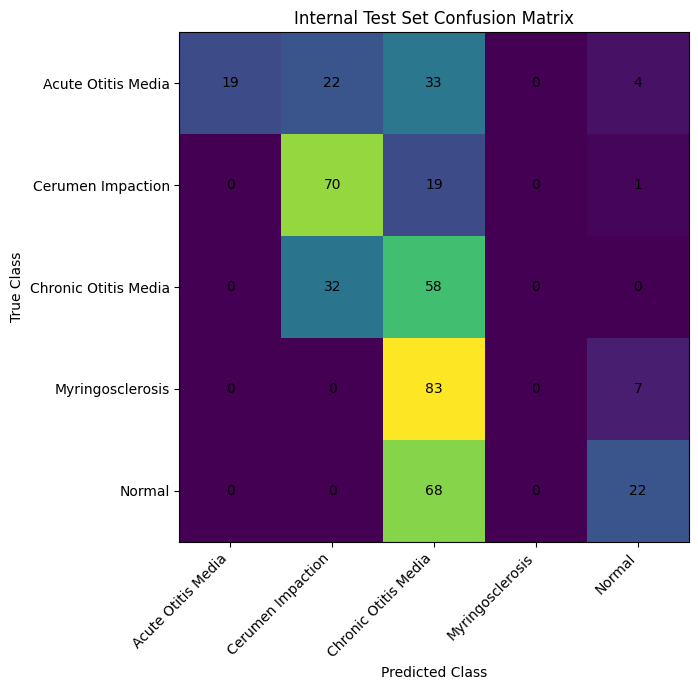

In [90]:
# ============================================================
# Cell 45 — Internal Test Confusion Matrix
# ============================================================

import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_true_labels,
    all_pred_labels,
    labels=list(range(1, len(class_names) + 1))
)

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print("\nRows    = True Class")
print("Columns = Predicted Class\n")

print("Classes:")
for i, name in enumerate(class_names, start=1):
    print(f"{i}: {name}")

print("\nConfusion Matrix:")
print(cm)

# Plot
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(cm)

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))

ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.set_title("Internal Test Set Confusion Matrix")

# Add numbers
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [91]:
# ============================================================
# Cell 46 — Save Final Internal Evaluation Results
# ============================================================

internal_results = {
    "test_images": len(test_data),
    "accuracy": accuracy,
    "macro_precision": precision,
    "macro_recall": recall,
    "macro_f1": f1,
    "mean_confidence": float(np.mean(all_scores)),
    "confusion_matrix": cm.tolist(),
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss
}

print("=" * 60)
print("FINAL INTERNAL EVALUATION SUMMARY")
print("=" * 60)

for key, value in internal_results.items():
    print(f"{key}: {value}")

print("=" * 60)
print("✓ Internal test results saved in memory.")

FINAL INTERNAL EVALUATION SUMMARY
test_images: 438
accuracy: 0.3858447488584475
macro_precision: 0.4867594349567784
macro_recall: 0.382051282051282
macro_f1: 0.34625624499159463
mean_confidence: 0.8736558817837337
confusion_matrix: [[19, 22, 33, 0, 4], [0, 70, 19, 0, 1], [0, 32, 58, 0, 0], [0, 0, 83, 0, 7], [0, 0, 68, 0, 22]]
best_epoch: 7
best_val_loss: 0.12478425191207365
✓ Internal test results saved in memory.


# Section 11 — External Validation

In [92]:
# ============================================================
# Section 11 — External Validation
# Cell 47 — External Dataset Setup
# ============================================================

import os
from pathlib import Path

print("=" * 60)
print("EXTERNAL VALIDATION")
print("=" * 60)

# External dataset classes that overlap with our trained model
external_class_mapping = {
    "Earwax Plug": "Cerumen Impaction",
    "Myringosclerosis": "Myringosclerosis",
    "Chronic Otitis Media": "Chronic Otitis Media",
    "Normal": "Normal"
}

# AOM is intentionally absent from this external dataset
print("External → Model class mapping:")
for ext_cls, model_cls in external_class_mapping.items():
    print(f"  {ext_cls:<25} → {model_cls}")

print("\nAOM:")
print("  Not available in this external dataset")

print("=" * 60)

EXTERNAL VALIDATION
External → Model class mapping:
  Earwax Plug               → Cerumen Impaction
  Myringosclerosis          → Myringosclerosis
  Chronic Otitis Media      → Chronic Otitis Media
  Normal                    → Normal

AOM:
  Not available in this external dataset


In [93]:
# ============================================================
# Cell 48 — Validation Error Analysis by Class
# ============================================================

from collections import Counter
import numpy as np
import torch

model.eval()

val_true_labels = []
val_pred_labels = []
val_scores = []

with torch.no_grad():
    for images, targets in val_loader:

        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):

            # Highest-confidence prediction
            if len(output["labels"]) > 0:
                best_idx = output["scores"].argmax()

                pred_label = output["labels"][best_idx].item()
                pred_score = output["scores"][best_idx].item()
            else:
                pred_label = 0
                pred_score = 0.0

            true_label = target["labels"][0].item()

            val_true_labels.append(true_label)
            val_pred_labels.append(pred_label)
            val_scores.append(pred_score)

# ------------------------------------------------------------
# Validation confusion matrix
# ------------------------------------------------------------

val_cm = confusion_matrix(
    val_true_labels,
    val_pred_labels,
    labels=list(range(1, len(class_names) + 1))
)

print("=" * 70)
print("VALIDATION SET ERROR ANALYSIS")
print("=" * 70)

print(f"Validation samples : {len(val_true_labels)}")
print(f"Mean confidence    : {np.mean(val_scores):.4f}")

print("\n" + "-" * 70)
print("PER-CLASS RESULTS")
print("-" * 70)

for i, class_name in enumerate(class_names):
    true_label = i + 1

    total = sum(
        1 for x in val_true_labels
        if x == true_label
    )

    correct = val_cm[i, i]

    recall = correct / total if total > 0 else 0

    print(
        f"{class_name:<25} "
        f"Correct: {correct:>3}/{total:<3} "
        f"Recall: {recall:.4f}"
    )

print("\n" + "-" * 70)
print("VALIDATION CONFUSION MATRIX")
print("-" * 70)

print(val_cm)

print("\nRows    = True Class")
print("Columns = Predicted Class")

print("=" * 70)

VALIDATION SET ERROR ANALYSIS
Validation samples : 438
Mean confidence    : 0.8710

----------------------------------------------------------------------
PER-CLASS RESULTS
----------------------------------------------------------------------
Acute Otitis Media        Correct:  17/78  Recall: 0.2179
Cerumen Impaction         Correct:  73/90  Recall: 0.8111
Chronic Otitis Media      Correct:  57/90  Recall: 0.6333
Myringosclerosis          Correct:   0/90  Recall: 0.0000
Normal                    Correct:  20/90  Recall: 0.2222

----------------------------------------------------------------------
VALIDATION CONFUSION MATRIX
----------------------------------------------------------------------
[[17 17 41  0  3]
 [ 0 73 15  0  2]
 [ 0 32 57  0  1]
 [ 0  0 81  0  9]
 [ 0  0 70  0 20]]

Rows    = True Class
Columns = Predicted Class
